# A5 CW Solutions: Fitting QNMs
### Joey Wee

- Let's start by examining and plotting the data.dat file.

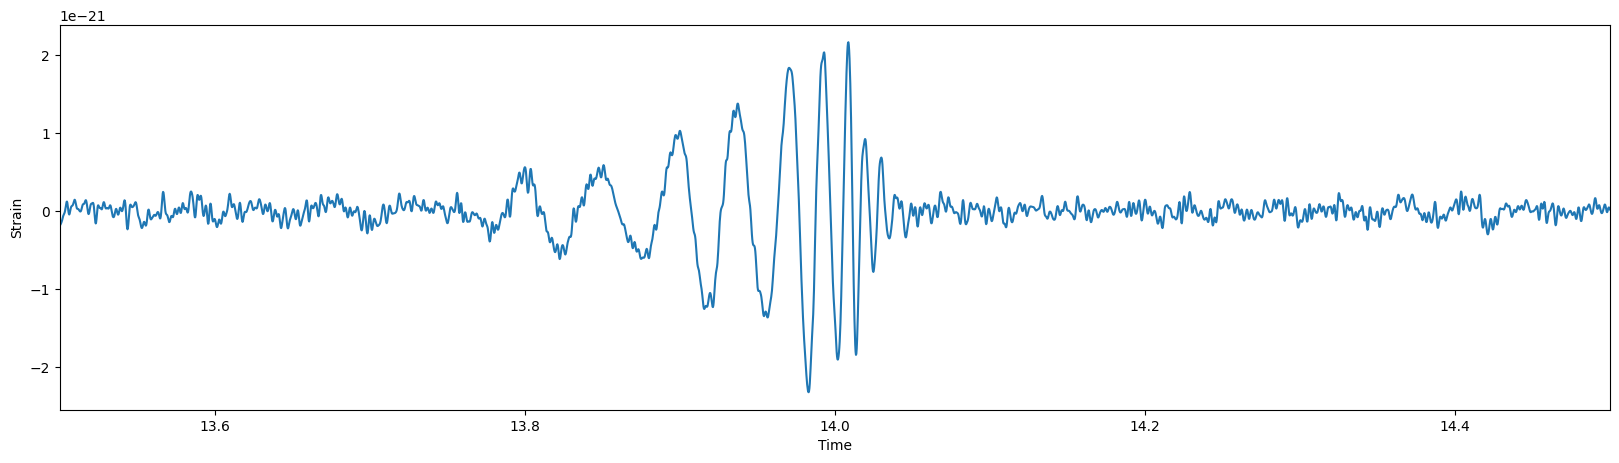

In [2]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('data.dat', skiprows=1)

fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Time")
ax.set_ylabel("Strain")
ax.plot(data[:,0], data[:,1])
ax.set_xlim(13.5,14.5)

t = data[:,0]
strain = data[:,1]


In [1]:
import qnm

# These are the some precomputed spin sequences
qnm.download_data()

Destination path C:\Users\Joey\.qnm\data-0.4.0.tar.bz2 already exists, use overwrite=True to force an overwrite.


- According to the no-hair theorem, any black hole can be described by the mass $M$ and the angular momentum $J = \chi M^2$, where $\chi$ is a dimensionless spin parameter $\chi \in [0,1[$ .

## Q1: Calculate the dimensionless frequencies
- Consider (l, m, n) = (2, 2, 0) and (3, 3, 0)
- Calculate the dimensionless frequencies $\hat{\omega}(M,\chi) = M\omega(\chi)$.
- Plot the real and imaginary parts of those frequencies.
    - The real part is the oscillatin' part.
    - The imaginary part causes the pertrubation to decay in time.


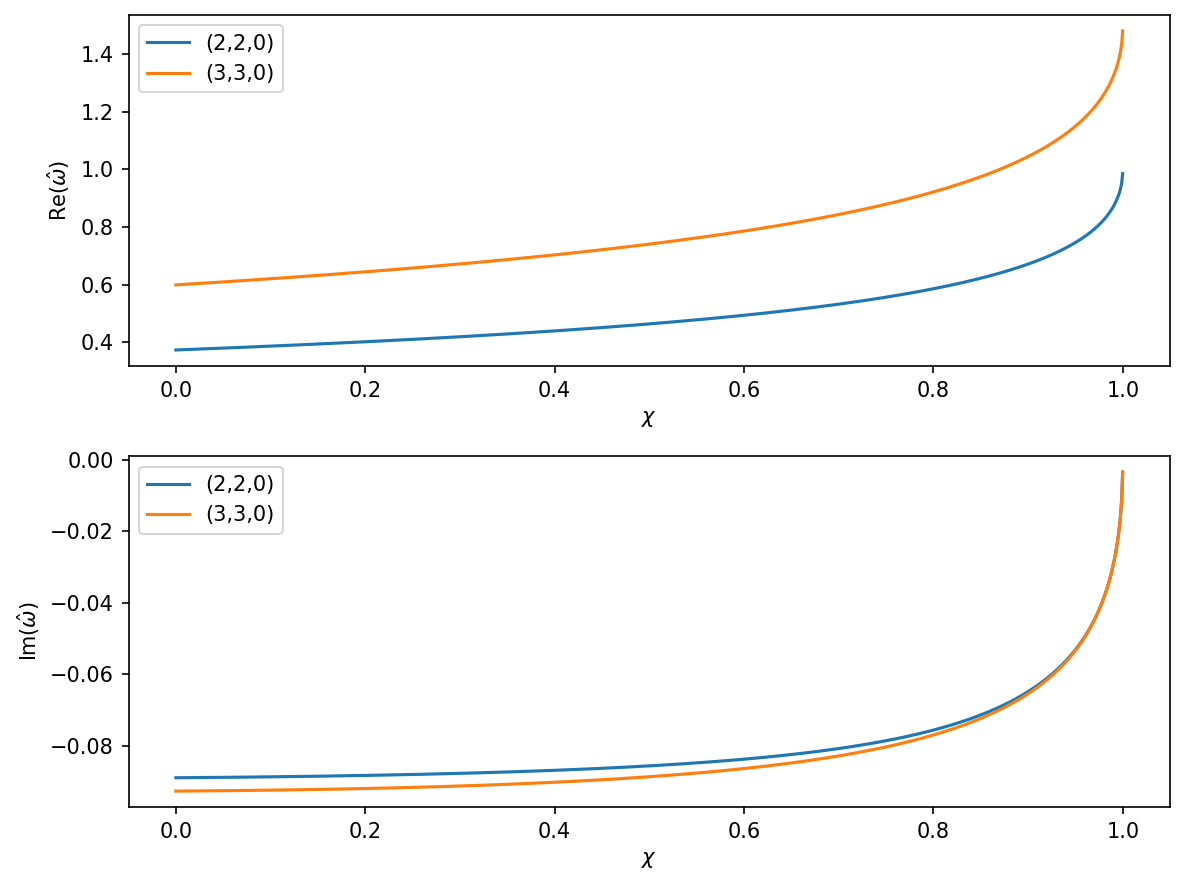

In [4]:
# The dense chi grid over which to calculate the dimensionless freqs
chi_values = np.linspace(0, 0.9999, 1000)

omega_220 = []
omega_330 = []

# Get mode objects
mode_220 = qnm.modes_cache(s=-2, l=2, m=2, n=0)
mode_330 = qnm.modes_cache(s=-2, l=3, m=3, n=0)

# Loop over chi values
for chi in chi_values:
    w220, _, _ = mode_220(chi)
    w330, _, _ = mode_330(chi)
    omega_220.append(w220)
    omega_330.append(w330)

# Convert to numpy arrays
omega_220 = np.array(omega_220)
omega_330 = np.array(omega_330)

# Now plot real and imaginary parts separately
fig, ax = plt.subplots(2, 1, figsize=(8, 6), dpi = 150)

ax[0].plot(chi_values, omega_220.real, label='(2,2,0)')
ax[0].plot(chi_values, omega_330.real, label='(3,3,0)')
ax[0].set_ylabel(r'$\mathrm{Re}(\hat{\omega})$')
ax[0].set_xlabel(r'$\chi$')
ax[0].legend()

ax[1].plot(chi_values, omega_220.imag, label='(2,2,0)')
ax[1].plot(chi_values, omega_330.imag, label='(3,3,0)')
ax[1].set_ylabel(r'$\mathrm{Im}(\hat{\omega})$')
ax[1].set_xlabel(r'$\chi$')
ax[1].legend()

plt.tight_layout()
plt.show()

## Q2: Splitting Data
- The data has off and on-source regimes corresponding to where there is and isn't any black hole merger signal.
- There is also a ringdown start time $t_0$ that corresponds.
- The off/on-signal bounds are loose bounds and it is not significant if there is some off-signal portion in the on-signal part.
- However, if there is on-signal data in the off-signal portion it will affect the off-signal analysis significantly.
----
- We start by examining the off/on-signal times. 
- Since this is a loose bound, we can do the identification by eye.
- We can better visualise the data by plotting a spectrogram.

#### Spectrogram

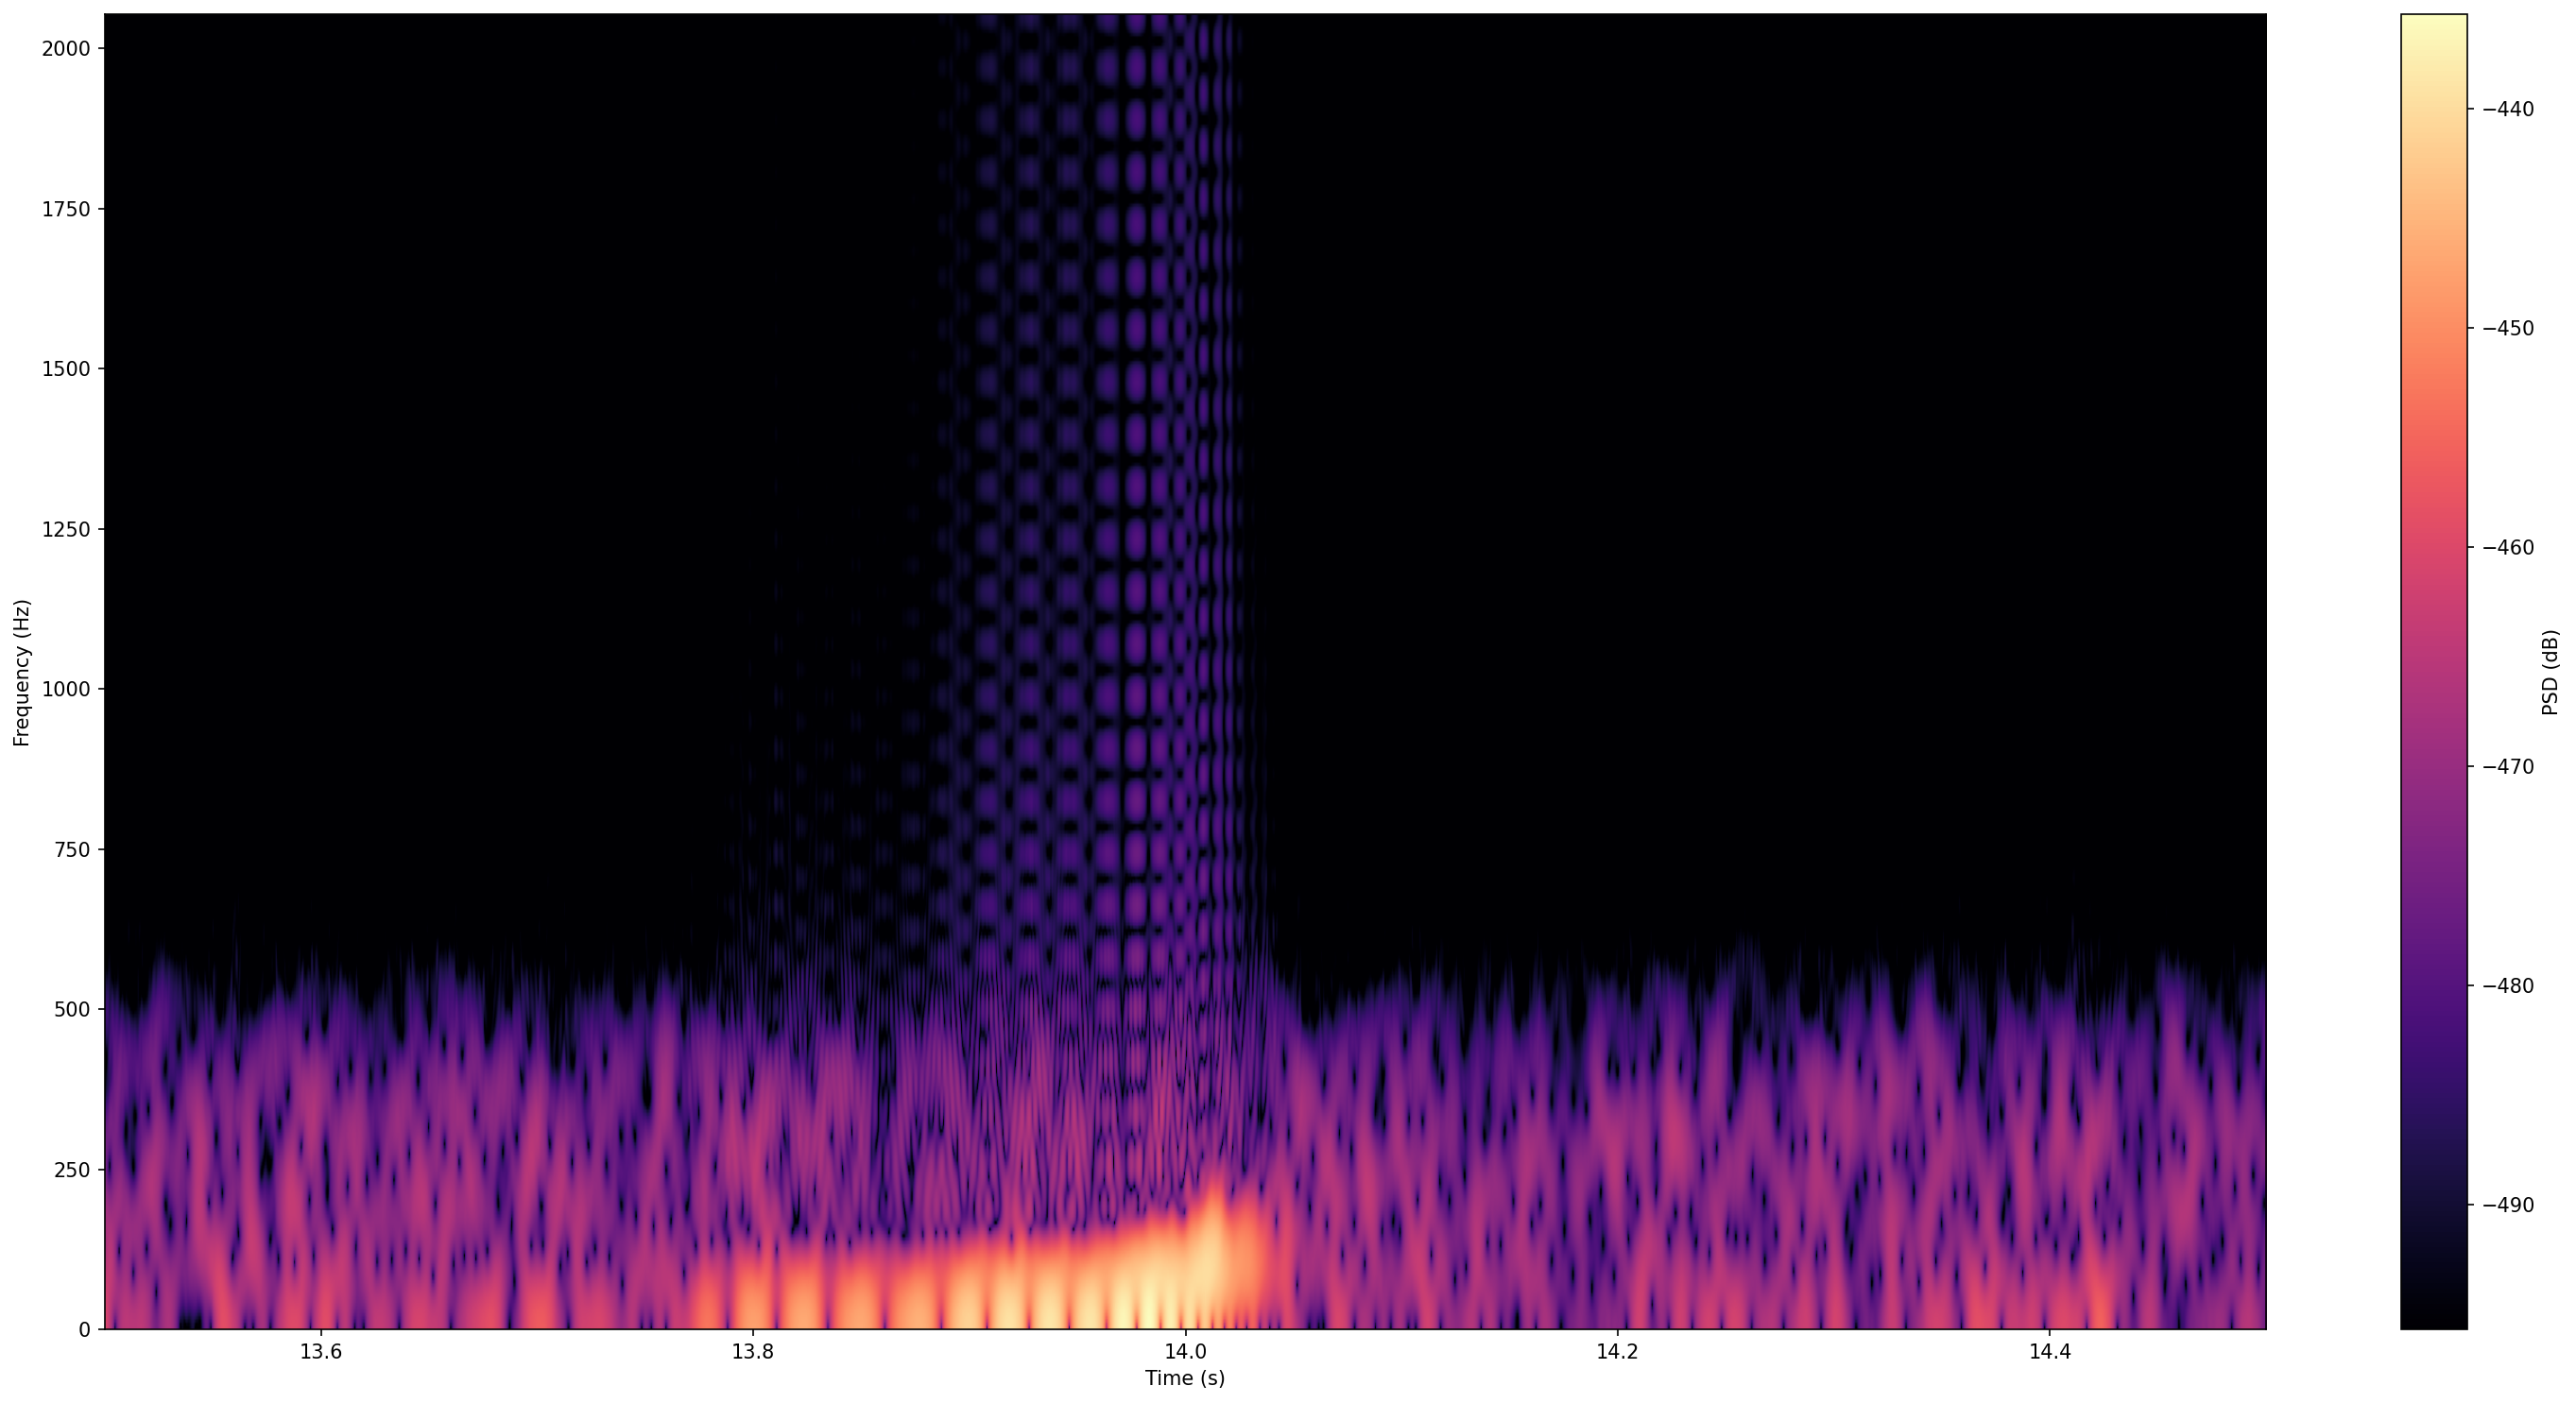

In [5]:
from scipy.signal import ShortTimeFFT
from scipy.signal.windows import gaussian


# 32 seconds of data at 4096 Hz 
T_x = 1/4096 # Time between samples
N = len(t) # Number of samples

# Time indices for the signal
t_x = np.arange(N) * T_x # N time ppoints spanning across N*T_x seconds

# Use Gaussian weighted windows to prevent spectral leakage
g_std = 12 # Width of Gaussian window
win  = gaussian(50, std=g_std, sym=True)
SFT = ShortTimeFFT(win, hop=2, fs=1/T_x, mfft=800, scale_to='psd')
Sx2 = SFT.spectrogram(strain) # Magnitude squared "x2"

# Convert into decibels for interpretability
Sx_dB = 10 * np.log10(np.fmax(Sx2, Sx2.max() * 1e-6))

# Plot the spectrogram
fig, ax = plt.subplots(figsize= (20,10), dpi=150)
t_lo, t_hi = SFT.extent(N)[:2] # Slightly wider time range because of the windows
ax.set_xlim(13.5,14.5) # Only look at the region around the on-period
im = ax.imshow(Sx_dB, origin='lower', aspect='auto', extent=SFT.extent(N), cmap='magma')
ax.set(xlabel='Time (s)', ylabel='Frequency (Hz)')
fig.colorbar(im, label='PSD (dB)')
fig.tight_layout()
plt.show()

In [7]:
on_time_start = 13.7
on_time_end = 14.1

- We can see here that, compared to the background, 13.8 to 14.0 is different.
- To make sure there is no on-signal time in the off-signal data, the bounds are extended by 100ms in each direction.
- This agrees with the strain vs time plot well (see below).

----
- Quasinormal modes decay in $t$. 
- It logically follows that at any time after the start time $t_0$, the signal will be weaker than at $t_0$. So, a starting estimate of $t_0$ will be time time of the peak amplitude of the strain.
- We can use a Hilbert transform the signal to get the amplitude term.
- We take the peak of this amplitude to be the start of our ringdown time $t_0$.
- If the $t_0$ is too early, the merger data will pollute the QNM fitting.
- If the $t_0$ is later, the fit will only have to contend with less signal-to-noise.
- The latter regime is less serious so we add 25 milliseconds to the Hilbert peak.

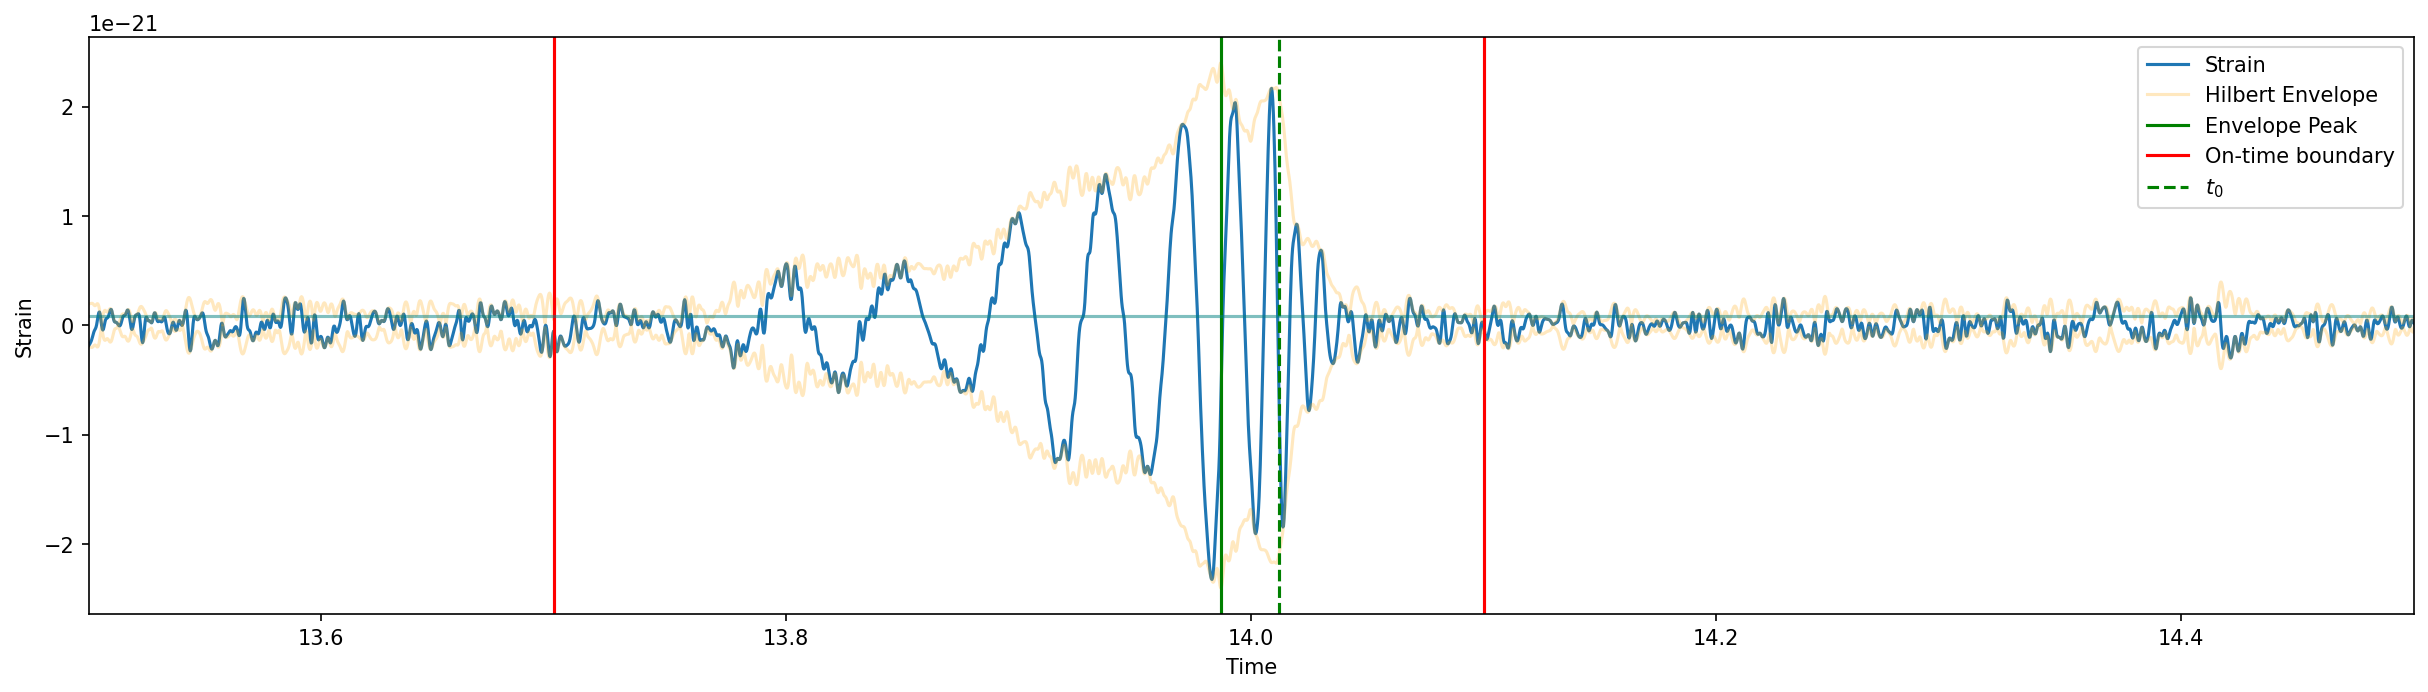

In [8]:
from scipy.signal import hilbert

# Hilbert transform
analytic = hilbert(strain)
envelope = np.abs(analytic)

# Initial t0 estimate
t0 = t[np.argmax(envelope)]

# Plot
fig, ax = plt.subplots(figsize = (20,5), dpi=150)
ax.set_xlabel("Time")
ax.set_ylabel("Strain")
ax.plot(t, strain, label='Strain')
ax.plot(t, envelope, alpha=0.25, label='Hilbert Envelope', color='orange')
ax.plot(t, -envelope, alpha=0.25, color='orange')
ax.axvline(t0, color='green', label='Envelope Peak')
ax.axvline(on_time_start, color='red', label='On-time boundary')
ax.axvline(on_time_end, color='red')
ax.axvline(t0+0.025, color='green', linestyle='dashed', label='$t_0$')
ax.axhline(8.32e-23, color='teal', alpha=0.5)
ax.set_xlim(13.5,14.5)
ax.legend()

In [9]:
t0_old = t0
t0 = t0+0.025 # The 25 millisecond buffer

## Q3: Estimate the $\sigma$
- I think it would be reasonable to use the standard deviation of the off-source data.

In [9]:
off_strain = strain[(t < on_time_start) | (t > on_time_end)]
off_std = np.std(off_strain)

print(f"Off standard deviation = {off_std:.4e}")

#------
t_on = t[(t > on_time_start) & (t < on_time_end)]
d_on = strain[(t > on_time_start) & (t < on_time_end)]

t_off_1 = t[(t < on_time_start)]
d_off_1 = strain[(t < on_time_start)]

t_off_2 = t[(t > on_time_end)]
d_off_2 = strain[(t > on_time_end)]

t_ring = t_on[t_on > t0]
d_ring = d_on[t_on > t0]

Off standard deviation = 8.3243e-23


## Q4: Sample parameters
- Priors:
    - A we dk amplitude so use 5x max ringdown strain as upper bound and 0 as a lower bound with log-uniform.
    - Phi is uniform between 0 and 2 pi.
    - f is log-uniform between 0 and the data frequency.
    - Tau is log-uniform between 0 and the data length.

In [10]:
def lnL(theta):
    A1, phi1, f1, tau1, A2, phi2, f2, tau2 = theta
    t = t_ring
    model = (A1 * np.cos(2*np.pi*f1*(t - t0) + phi1) * np.exp(-(t - t0)/tau1) +
             A2 * np.cos(2*np.pi*f2*(t - t0) + phi2) * np.exp(-(t - t0)/tau2))
    residuals = d_ring - model  # d is your on-source data, t > t0
    return -0.5 * np.sum(residuals**2 / off_std**2)

def prior_transform(u):
    A1_u, phi1_u, f1_u, tau1_u, A2_u, phi2_u, f2_u, tau2_u = u

    # log-uniform on amplitudes 
    # A_min, A_max = 1e-25, 1e-19 
    A_min, A_max = 1e-25, 1e-20
    A1   = A_min * (A_max / A_min) ** A1_u
    A2   = A_min * (A_max / A_min) ** A2_u

    # uniform on phases [-pi, pi]
    phi1 = -np.pi + phi1_u * 2 * np.pi
    phi2 = -np.pi + phi2_u * 2 * np.pi

    # log-uniform on frequencies 
    # f_min, f_max = 20.0, 4096.0 
    f_min, f_max = 20.0, 400
    f1   = f_min * (f_max / f_min) ** f1_u
    f2   = f_min * (f_max / f_min) ** f2_u

    # log-uniform on damping times 
    tau_min, tau_max = 1e-4, 1e-1
    tau1 = tau_min * (tau_max / tau_min) ** tau1_u
    tau2 = tau_min * (tau_max / tau_min) ** tau2_u

    return [A1, phi1, f1, tau1, A2, phi2, f2, tau2]

In [11]:
import dynesty

np.random.seed(1701)

sampler = dynesty.DynamicNestedSampler(
    lnL,
    prior_transform,
    ndim=8,
    bound='multi',    # multiellipsoid bounding
    sample='rwalk'    # random walk sampling
)

sampler.run_nested(print_progress=True)

30848it [02:37, 195.92it/s, batch: 5 | bound: 6 | nc: 1 | ncall: 804333 | eff(%):  3.772 | loglstar: -186.161 < -178.685 < -180.269 | logz: -219.981 +/-  0.210 | stop:  0.850]         


In [12]:
from dynesty import utils as dyfunc

results = sampler.results

# Resample to equal weights (important — dynesty samples are not equal weight)
weights = np.exp(results.logwt - results.logz[-1])
samples = dyfunc.resample_equal(results.samples, weights)

# samples has shape (N, 8)
# columns match your parameter order: A1, phi1, f1, tau1, A2, phi2, f2, tau2
A1, phi1, f1, tau1 = samples[:,0], samples[:,1], samples[:,2], samples[:,3]
A2, phi2, f2, tau2 = samples[:,4], samples[:,5], samples[:,6], samples[:,7]

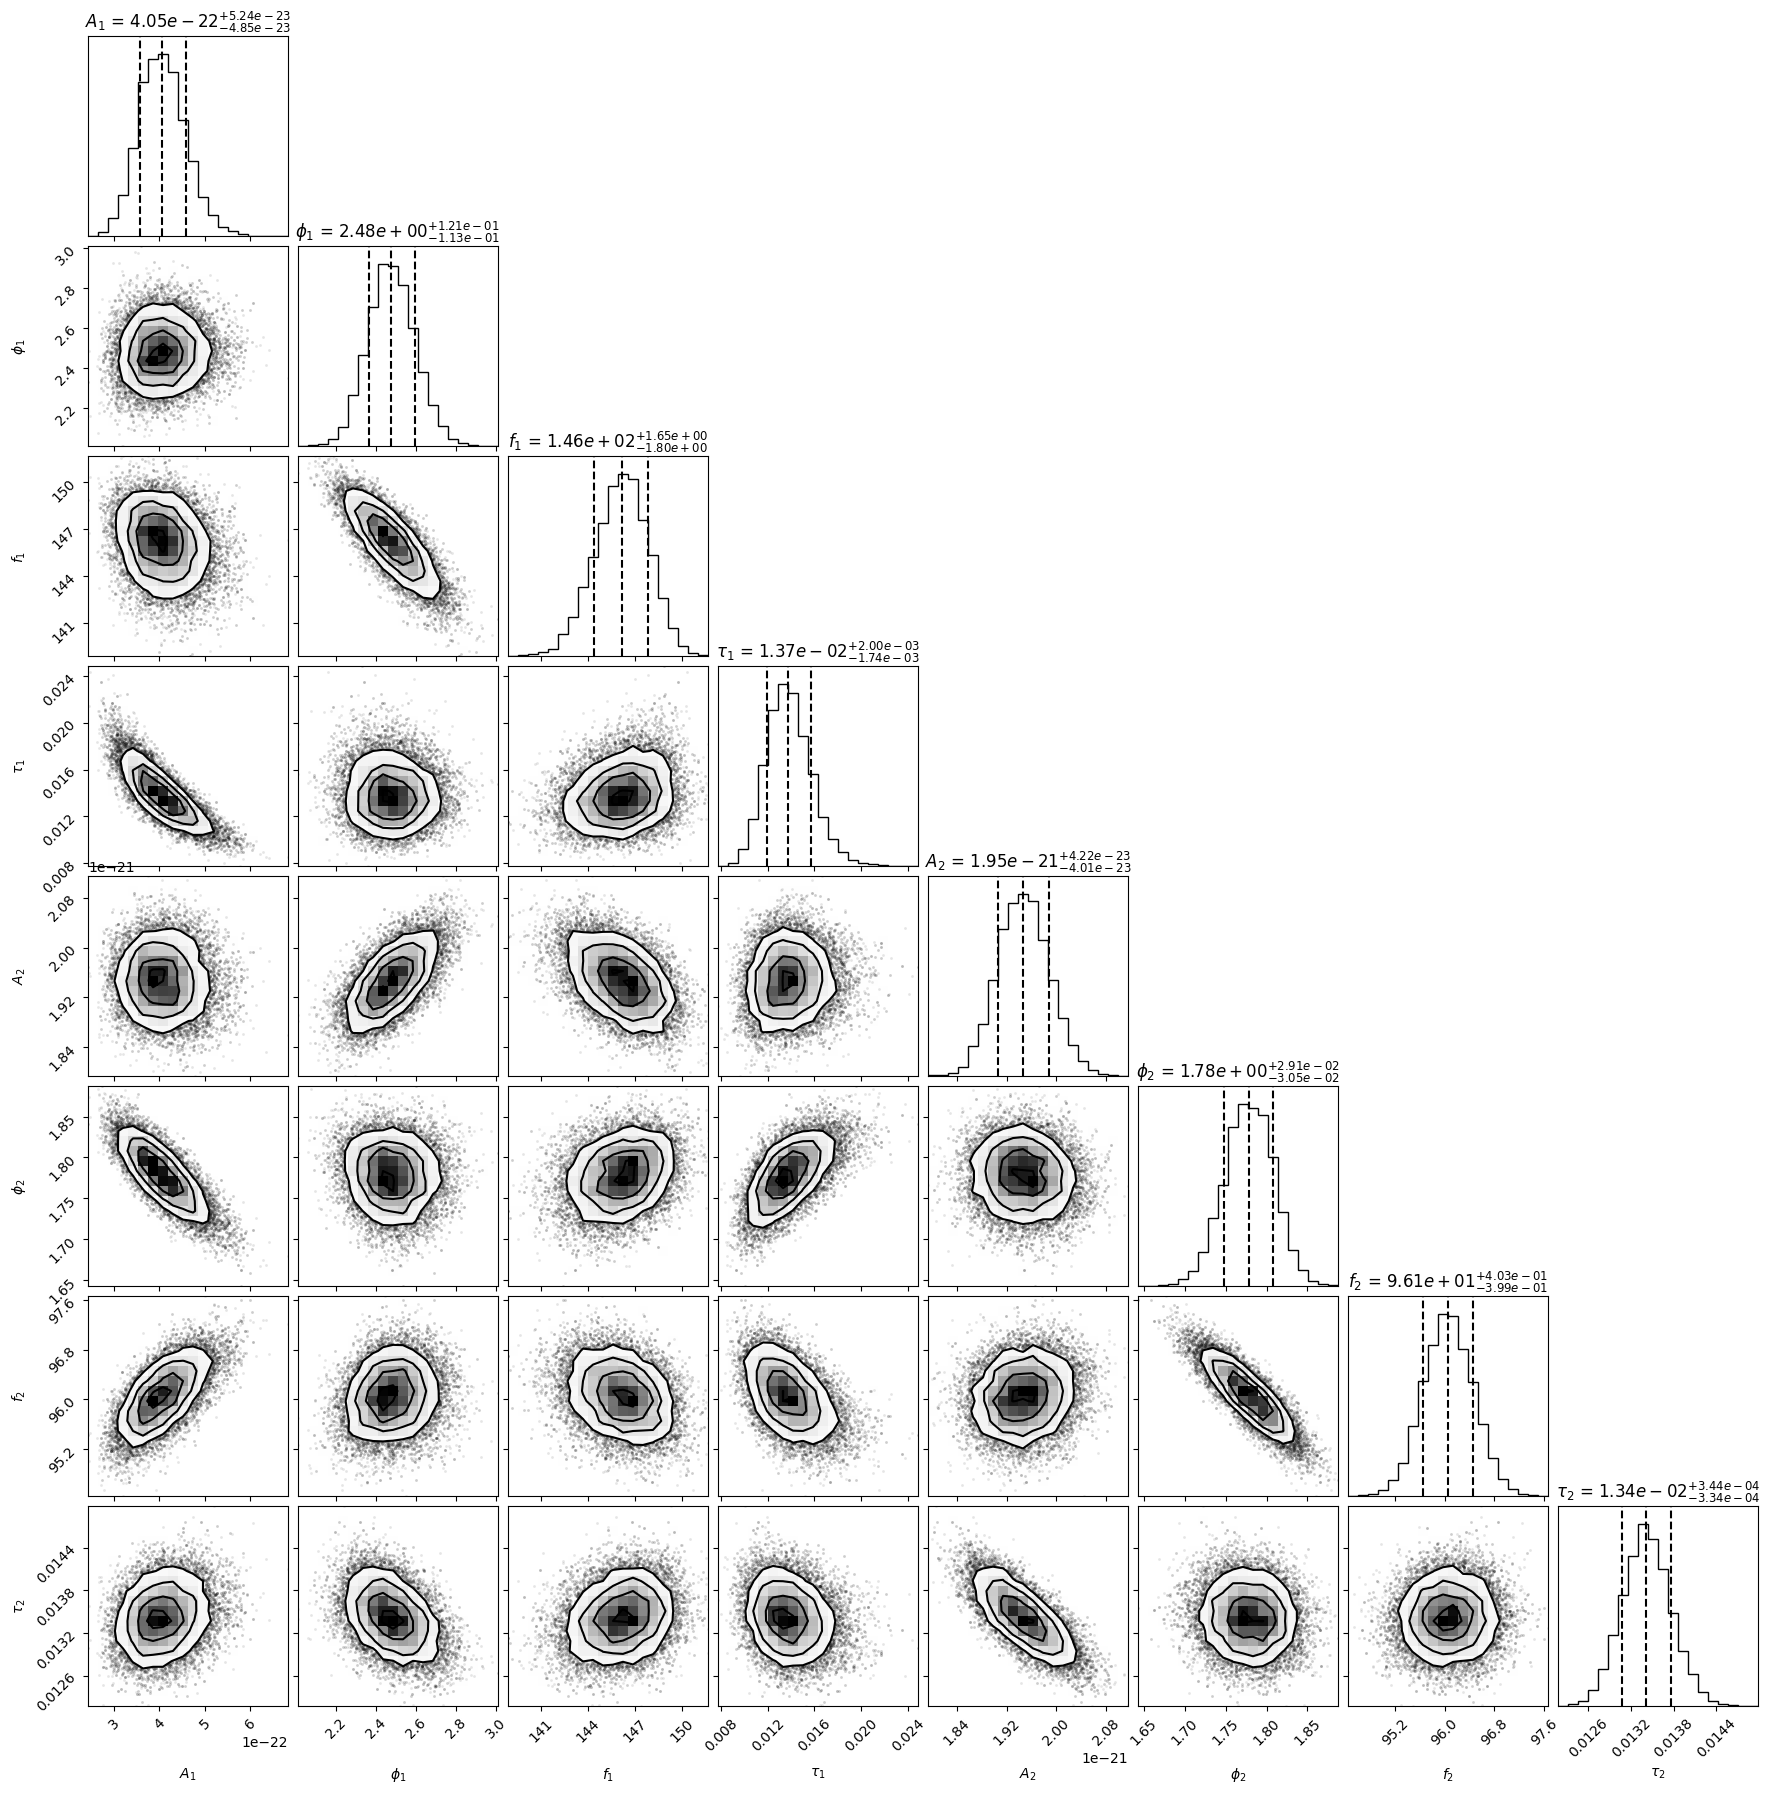

In [13]:
import corner

labels = [r"$A_1$", r"$\phi_1$", r"$f_1$", r"$\tau_1$",
          r"$A_2$", r"$\phi_2$", r"$f_2$", r"$\tau_2$"]

fig = corner.corner(
    samples,
    labels=labels,
    quantiles=[0.16, 0.5, 0.84],  # 1-sigma credible intervals
    show_titles=True,
    title_fmt=".2e",
)

- Plotting just f and tau.

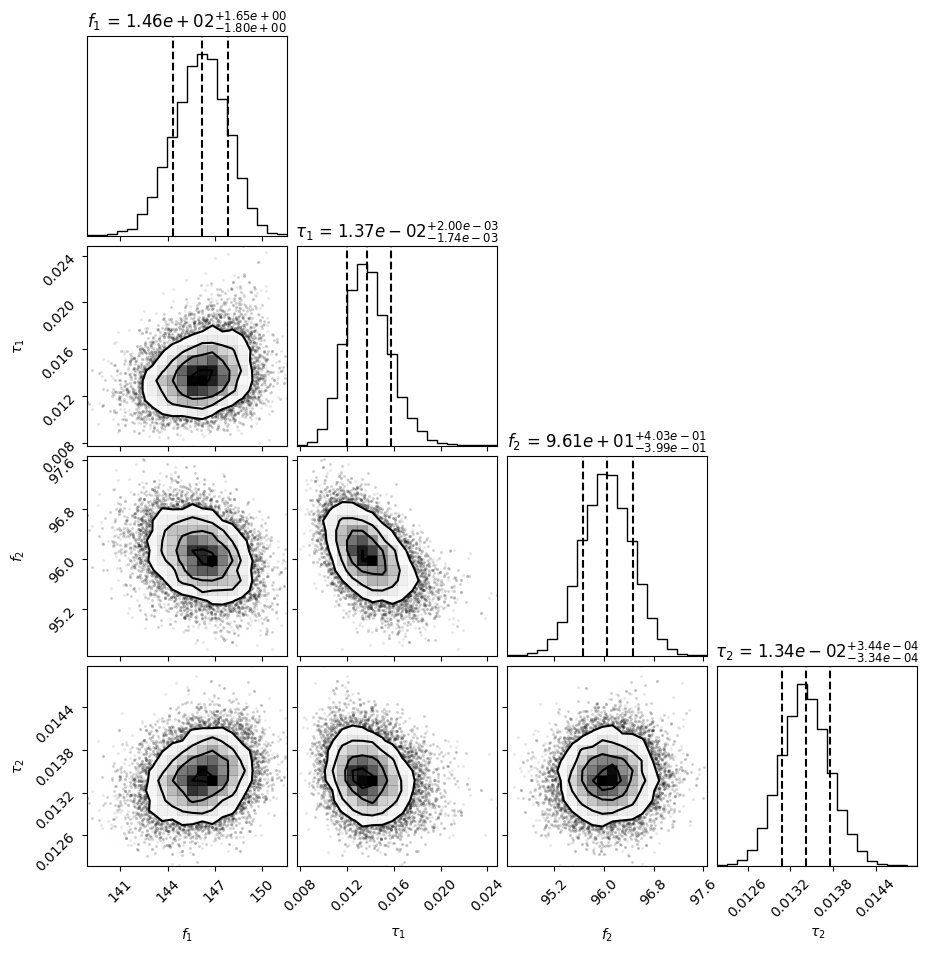

In [14]:
labels =  [r"$f_1$", r"$\tau_1$",
            r"$f_2$", r"$\tau_2$"]

samples_subset = samples[:, [2, 3, 6, 7]] # extract f and tau columns

fig = corner.corner(
    samples_subset,
    labels=labels,
    quantiles=[0.16, 0.5, 0.84],  # 1-sigma credible intervals
    show_titles=True,
    title_fmt=".2e",
    dpi=150
)

- Plot the residuals of the fits.

Text(0.5, 0, 'Time')

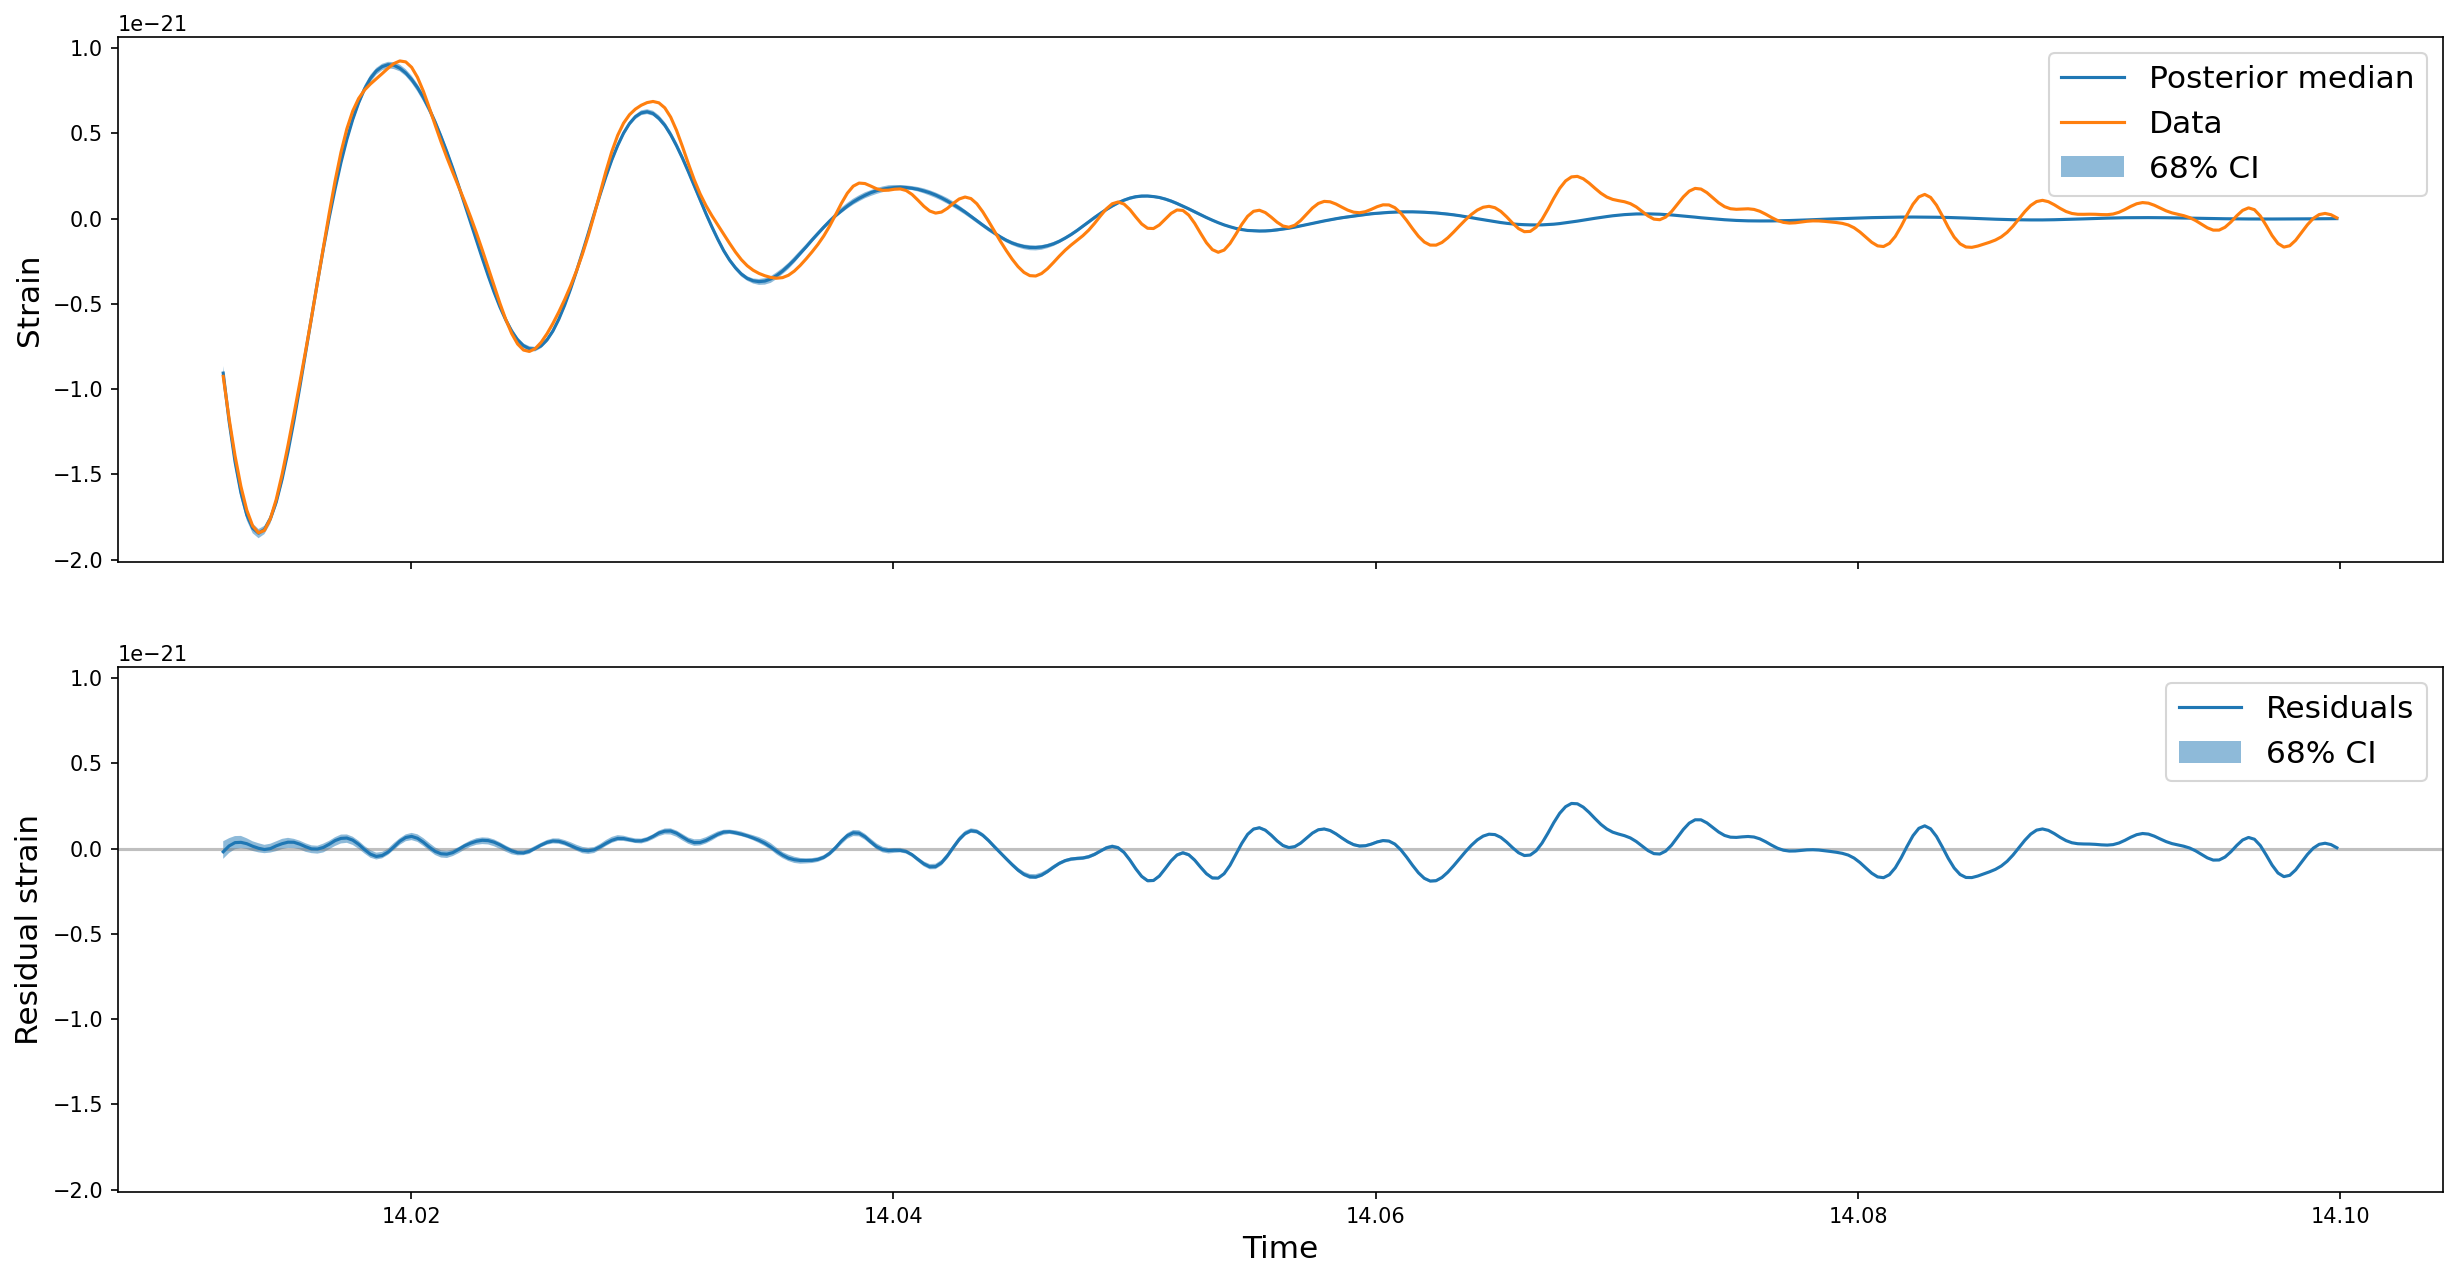

In [18]:
preds = []
for sample in samples[:100,:]:
    # sample is in (N_params,)
    A1, phi1, f1, tau1 = sample[0], sample[1], sample[2], sample[3]
    A2, phi2, f2, tau2 = sample[4], sample[5], sample[6], sample[7]
    pred = (A1 * np.cos(2*np.pi*f1*(t_ring - t0) + phi1) * np.exp(-(t_ring - t0)/tau1) +
             A2 * np.cos(2*np.pi*f2*(t_ring - t0) + phi2) * np.exp(-(t_ring - t0)/tau2))
    preds.append(pred)

pred_16 = np.percentile(preds, 16, axis=0)
pred_50 = np.percentile(preds, 50, axis=0)
pred_84 = np.percentile(preds, 84, axis=0)

fig, ax = plt.subplots(2,1,figsize=(20,10), sharey=True, sharex=True, dpi=150)
ax[0].plot(t_ring, pred_50, label='Posterior median')
ax[0].plot(t_ring, d_ring, label='Data')
ax[0].fill_between(t_ring, pred_84, pred_16, alpha=0.5, label='68% CI')
ax[0].legend(fontsize=15)
ax[0].set_ylabel("Strain",fontsize=15)

resid_50 = d_ring - pred_50
resid_16 = d_ring - pred_16
resid_84 = d_ring - pred_84

ax[1].axhline(0, alpha=0.5, color='grey')
ax[1].plot(t_ring, resid_50, label='Residuals')
ax[1].fill_between(t_ring, resid_84, resid_16, alpha=0.5, label='68% CI')
ax[1].legend(fontsize=15)
ax[1].set_ylabel("Residual strain",fontsize=15)
ax[1].set_xlabel("Time",fontsize=15)


## Q5: Off-source PSD
- The problem is that the concatenation of the two off-source sections would lead to signal bleed.
- I will take a PSD for each and then average them.

In [10]:
from scipy.signal import welch

fs = 4096
f_1, PSD_1 = welch(d_off_1, fs=fs, nperseg=256, noverlap=128, window='hann')
f_2, PSD_2 = welch(d_off_2, fs=fs, nperseg=256, noverlap=128, window='hann')
# f = frequency array, PSD = power spectral density
PSD_mean = np.mean([PSD_1, PSD_2], axis=0)

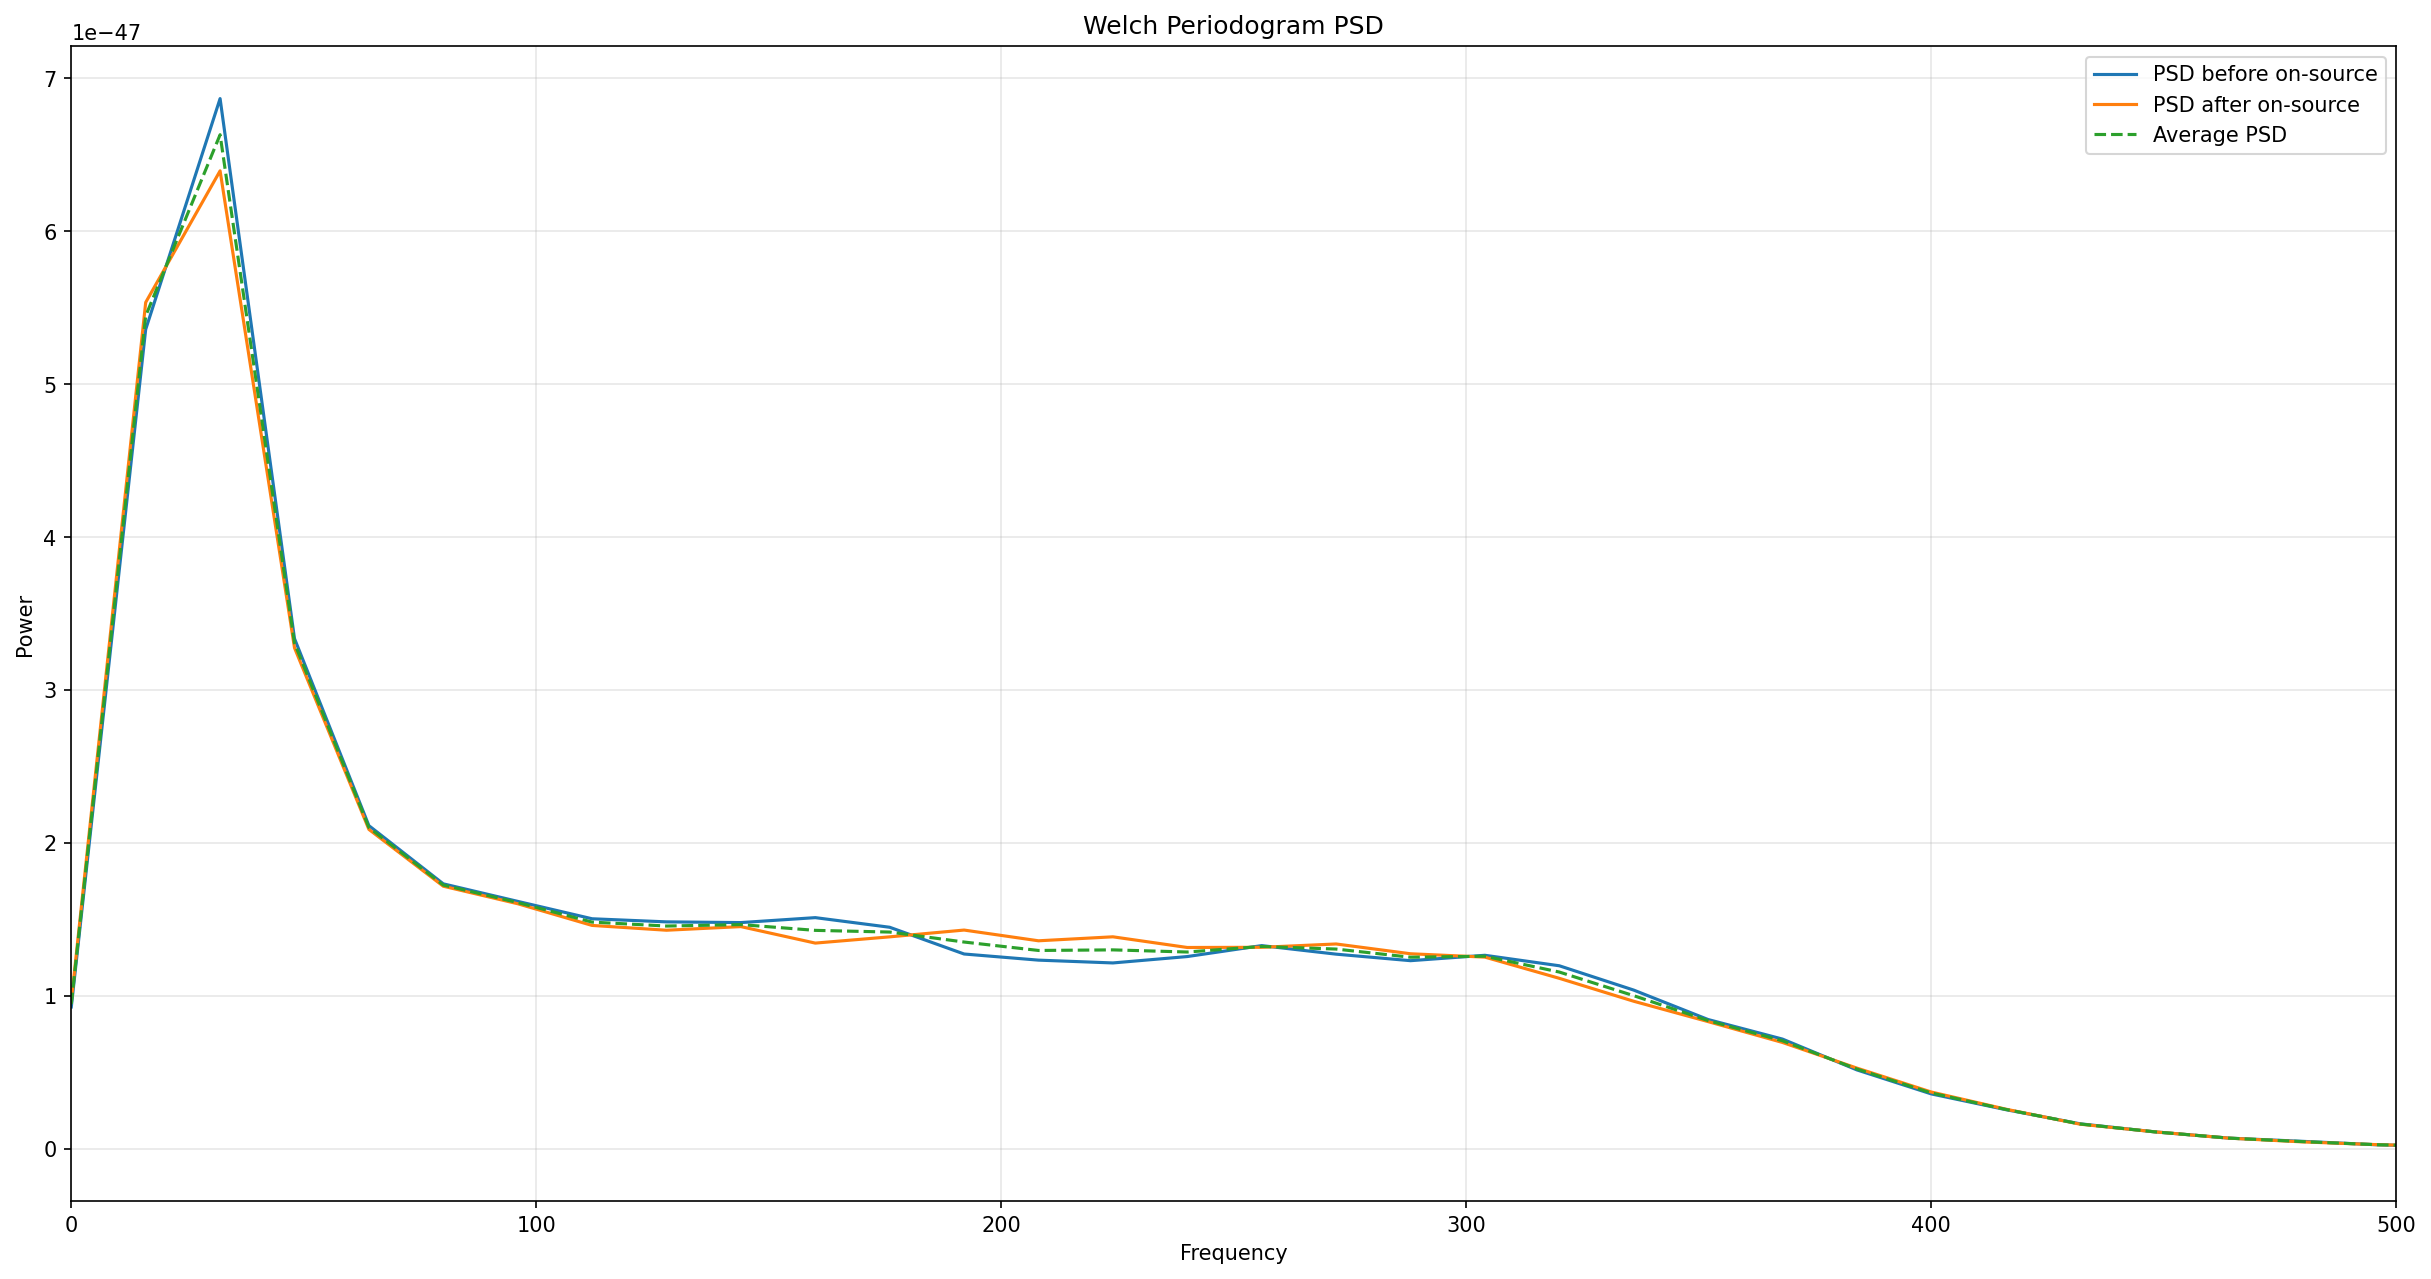

In [11]:
fig, ax = plt.subplots(figsize = (20,10), dpi=150)
ax.set_xlabel("Frequency")
ax.set_ylabel("Power")
ax.plot(f_1, PSD_1, label='PSD before on-source')
ax.plot(f_2, PSD_2, label='PSD after on-source')
ax.plot(f_1, PSD_mean, linestyle='dashed', alpha=1,label='Average PSD')
ax.set_title("Welch Periodogram PSD")
ax.set_xlim(0,500)
ax.grid(True, alpha=0.3)
ax.legend()



- Let's examine the instrument noise PSD.

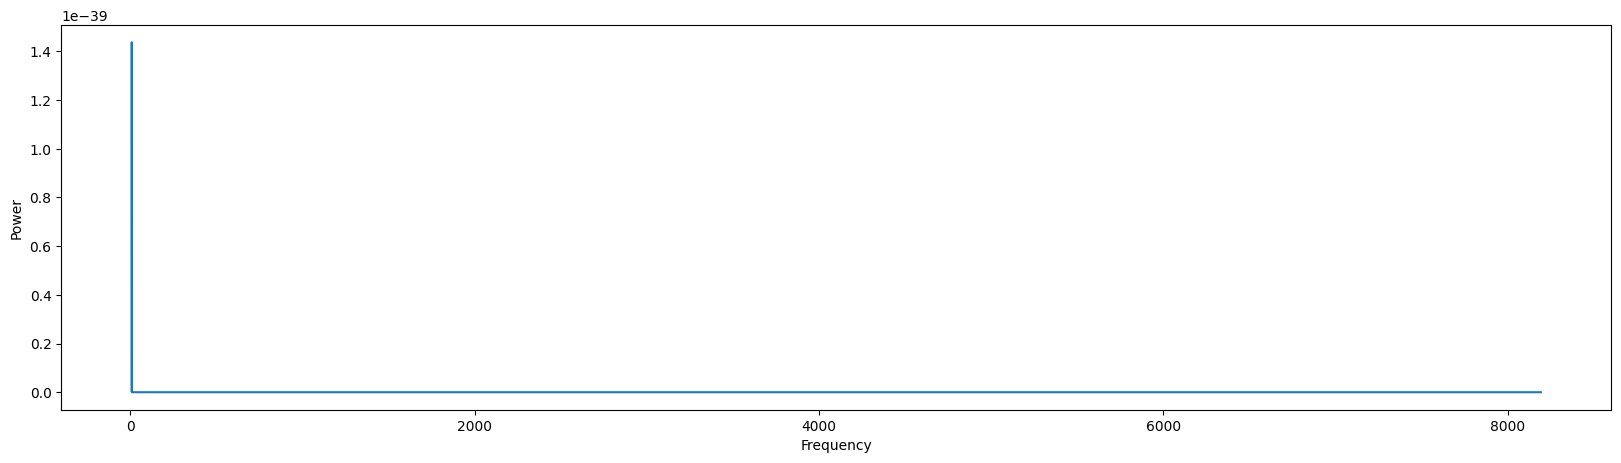

In [12]:
instrument_PSD = np.loadtxt('psd.dat', skiprows=1)
fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Frequency")
ax.set_ylabel("Power")
ax.plot(instrument_PSD[:,0], instrument_PSD[:,1])


- These should be estimates of the same thing.
- Rescale them to plot together.

(0.0, 1000.0)

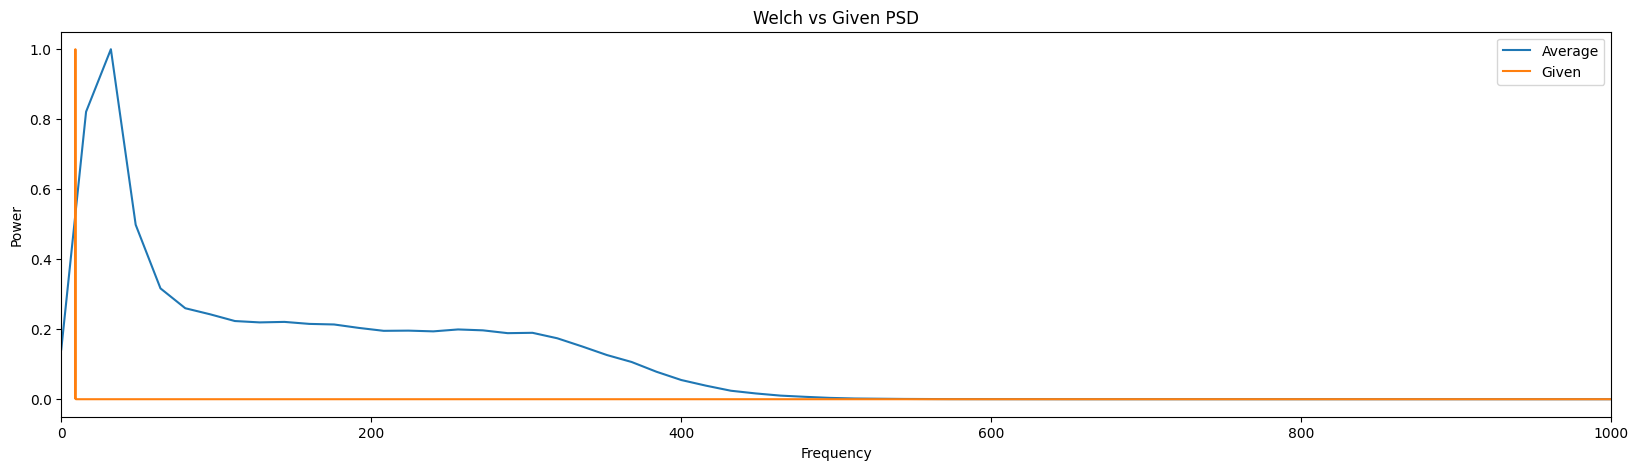

In [13]:
fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Frequency")
ax.set_ylabel("Power")

PSD_mean_rescaled = PSD_mean / max(PSD_mean)
PSD_instrument_rescaled = instrument_PSD[:,1] / max(instrument_PSD[:,1])

ax.plot(f_1, PSD_mean_rescaled, label='Average')
ax.plot(instrument_PSD[:,0], PSD_instrument_rescaled, label="Given")
ax.set_title("Welch vs Given PSD")
ax.legend()
ax.set_xlim(0,1000)


- The Welch periodogram is an empirical approximation so this doesn't seem too bad. Lower frequencies would require more data to be accurate so given limited data this seems reasonable.
- Sensible given the bandpass of 20-400 Hz.

## Q6: Calculate TDACF 
- If the white noise likelihood holds, the TDACF should be concentrates at 0 (subsequent points are uncorrelated).
- ACF and PSD are FFT pair.

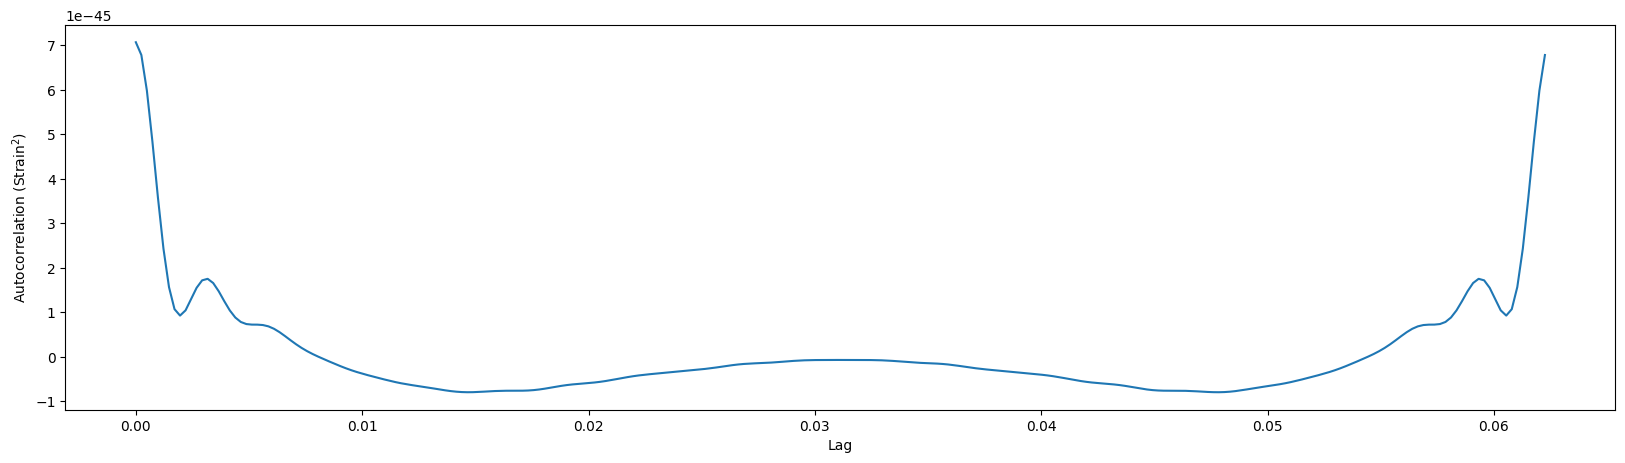

In [14]:
df = f_1[1] - f_1[0]  # sampling interval
N = 2 * (len(PSD_mean) - 1)

N_data = len(PSD_1) + len(PSD_2)# Len of the data
c95 = 1.96 / np.sqrt(N_data)

C = np.fft.irfft(PSD_mean) * df * N / 2   # units: strain²
tau = np.arange(N) * (1 / (N * df))  # lag axis in seconds


fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation (Strain$^2$)")
ax.plot(tau, C)

- This has two lobes because the IRFFT calculates positive and negative lags cyclically.
- Let's plot the first half.

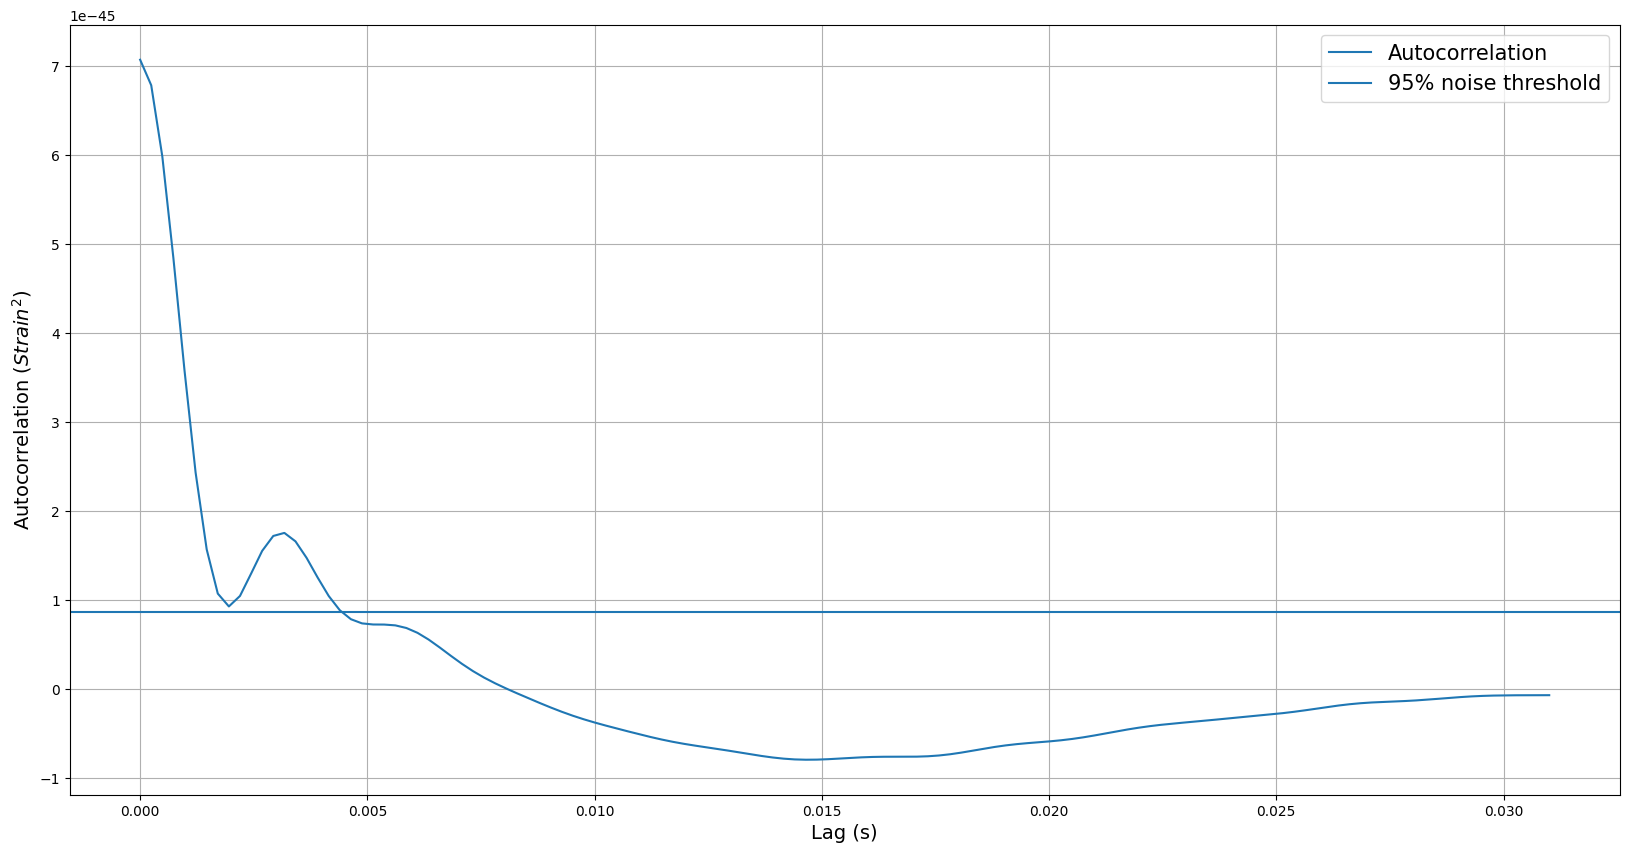

In [23]:
fig, ax = plt.subplots(figsize = (20,10))

ax.set_xlabel("Lag (s)", fontsize=14)
ax.set_ylabel("Autocorrelation ($Strain^2$)", fontsize=14)

ax.grid()

scaled_c95 =c95 * C[0]

N = len(tau)
ax.plot(tau[:N//2], C[:N//2], label='Autocorrelation')
ax.axhline(scaled_c95, label='95% noise threshold')

ax.legend(fontsize=15)

- This is more or less like white noise: our white noise kernel is a good choice.
- There is a peak that sits above the noise that is above the 95% confidence for noise so there is probably some other effect in the data.
- The tau = 0 lag is dominant though so I think the white noise kernel is still applicable.

In [41]:
tau[0], C[0]

(np.float64(0.0), np.float64(7.070439650219172e-45))

## Q7: Relating off_std to the ACF


In [ ]:
rel = (C[0] - (off_std ** 2)) / (off_std ** 2)
print(f'Relative difference between variance and ACF at 0 lag is {rel:.2f}%')
s

Relative difference between variance and ACF at 0 lag is 0.02%


np.float64(8.324320250575012e-23)

- This is pretty close.
- We would expace these values to be the same because of the autocorrelation definition $$R(\tau) = \left\langle x(t) \cdot x(t+\tau) \right\rangle_t$$.
- At tau = 0, we just expect the variance.

## Q8: GR and Kerr Metric Consistency Test
- Describe how.
- Perform it using this signal.

- Under the no-hair theorem, a black hole is fully characterised by $M$ and $\chi$.
- Each complex frequency $\omega_\alpha(M, \chi) = \frac{\hat\omega_\alpha(\chi)}{M}$
- $\hat\omega_\alpha(\chi)$ is fixed by GR.
- Every $\alpha$-mode is a function of the same two parameters.
- We have fit two modes from which we have extracted values of $f_\alpha = \frac{1}{2\pi} (\omega_\alpha + \frac{i}{\tau_\alpha})$ and $\tau_\alpha$.
- These values can be used to solve for $M$ and $\chi$.
- If GR is correct, these should line up (unless there is some deviation from the Kerr black hole ie exotic objects).

In [19]:
# 16th, 50th (median), 84th percentiles for each parameter
lo, med, hi = np.percentile(samples, [16, 50, 84], axis=0)

f1_med = med[2]
f1_lo, f1_hi = lo[2], hi[2]

f2_med = med[6]
f2_lo, f2_hi = lo[6], hi[6]

tau1_med = med[3]
tau1_lo, tau1_hi = lo[3], hi[3]

tau2_med = med[7]
tau2_lo, tau2_hi = lo[7], hi[7]

# Switch if required
# 220 mode has the lower frequency = f2 so switch dynamicall
if f2_med > f1_med:  
    f1_med, f2_med = f2_med, f1_med
    f1_lo,  f2_lo  = f2_lo,  f1_lo
    f1_hi,  f2_hi  = f2_hi,  f1_hi
    tau1_med, tau2_med = tau2_med, tau1_med
    tau1_lo,  tau2_lo  = tau2_lo,  tau1_lo
    tau1_hi,  tau2_hi  = tau2_hi,  tau1_hi

print("After: f2 is 220 so must be lower f")
print(f"f1_med = {f1_med:.1f} Hz")
print(f"f2_med = {f2_med:.1f} Hz")

# Calculate chi intercept for 330

omega_330_ratio = omega_330.real / np.abs(omega_330.imag)

target_330 = 2 * np.pi * f1_med * tau1_med
lo_330 = 2 * np.pi * f1_lo * tau1_lo
hi_330 = 2 * np.pi * f1_hi * tau1_hi

# Find the argument of the target in the ratio using interpolation

chi_med_330 = np.interp(target_330, omega_330_ratio, chi_values)
chi_lo_330  = np.interp(lo_330, omega_330_ratio, chi_values)
chi_hi_330  = np.interp(hi_330, omega_330_ratio, chi_values)

# Calculate chi intercept for 220
omega_220_ratio = omega_220.real / np.abs(omega_220.imag)

target_220 = 2 * np.pi * f2_med * tau2_med
lo_220 = 2 * np.pi * f2_lo * tau2_lo
hi_220 = 2 * np.pi * f2_hi * tau2_hi

# Find the argument of the target in the ratio using interpolation

chi_med_220 = np.interp(target_220, omega_220_ratio, chi_values)
chi_lo_220  = np.interp(lo_220, omega_220_ratio, chi_values)
chi_hi_220  = np.interp(hi_220, omega_220_ratio, chi_values)

# Calculate the masses
def convert_to_Msun(Mseconds):
    return Mseconds * 2.03e5

# Calculate Masses for 220 mode (f2 is the 220 frequency ~96 Hz)
omega_hat_med_220, _, _ = mode_220(chi_med_220)
omega_hat_lo_220, _, _  = mode_220(chi_lo_220)
omega_hat_hi_220, _, _  = mode_220(chi_hi_220)

M_med_220 = omega_hat_med_220.real / (2 * np.pi * f2_med)
M_lo_220  = omega_hat_lo_220.real  / (2 * np.pi * f2_hi)
M_hi_220  = omega_hat_hi_220.real  / (2 * np.pi * f2_lo)

M_med_220 = convert_to_Msun(M_med_220)
M_lo_220  = convert_to_Msun(M_lo_220)
M_hi_220  = convert_to_Msun(M_hi_220)

# Calculate Masses for 330 mode (f1 is the 330 frequency ~146 Hz)
omega_hat_med_330, _, _ = mode_330(chi_med_330)
omega_hat_lo_330, _, _  = mode_330(chi_lo_330)
omega_hat_hi_330, _, _  = mode_330(chi_hi_330)

M_med_330 = omega_hat_med_330.real / (2 * np.pi * f1_med)
M_lo_330  = omega_hat_lo_330.real  / (2 * np.pi * f1_hi)
M_hi_330  = omega_hat_hi_330.real  / (2 * np.pi * f1_lo)

M_med_330 = convert_to_Msun(M_med_330)
M_lo_330  = convert_to_Msun(M_lo_330)
M_hi_330  = convert_to_Msun(M_hi_330)

# Print the results
from prettytable import PrettyTable

table = PrettyTable()
table.field_names = ["Mode", "χ (16th)", "χ (median)", "χ (84th)"]
table.add_row(["(2,2,0)", f"{chi_lo_220:.4f}", f"{chi_med_220:.4f}", f"{chi_hi_220:.4f}"])
table.add_row(["(3,3,0)", f"{chi_lo_330:.4f}", f"{chi_med_330:.4f}", f"{chi_hi_330:.4f}"])
print(table)

table = PrettyTable()
table.field_names = ["Mode", "M_low", "M_med", "M_high"]
table.add_row(["(2,2,0)", f"{M_lo_220:.2f}", f"{M_med_220:.2f}", f"{M_hi_220:.2f}"])
table.add_row(["(3,3,0)", f"{M_lo_330:.2f}", f"{M_med_330:.2f}", f"{M_hi_330:.2f}"])
print(table)

After: f2 is 220 so must be lower f
f1_med = 146.2 Hz
f2_med = 96.1 Hz
+---------+----------+------------+----------+
|   Mode  | χ (16th) | χ (median) | χ (84th) |
+---------+----------+------------+----------+
| (2,2,0) |  0.8069  |   0.8203   |  0.8328  |
| (3,3,0) |  0.7445  |   0.8232   |  0.8763  |
+---------+----------+------------+----------+
+---------+--------+--------+--------+
|   Mode  | M_low  | M_med  | M_high |
+---------+--------+--------+--------+
| (2,2,0) | 197.80 | 201.74 | 205.67 |
| (3,3,0) | 191.26 | 208.83 | 225.73 |
+---------+--------+--------+--------+


<ErrorbarContainer object of 3 artists>

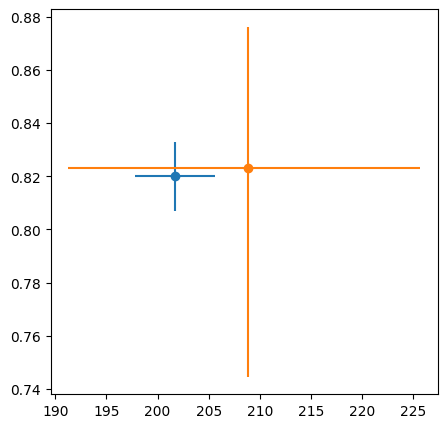

In [20]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.errorbar(M_med_220, chi_med_220,
            xerr=[[M_med_220 - M_lo_220], [M_hi_220 - M_med_220]],
            yerr=[[chi_med_220 - chi_lo_220], [chi_hi_220 - chi_med_220]],
            marker='o')

ax.errorbar(M_med_330, chi_med_330,
            xerr=[[M_med_330 - M_lo_330], [M_hi_330 - M_med_330]],
            yerr=[[chi_med_330 - chi_lo_330], [chi_hi_330 - chi_med_330]],
            marker='o')

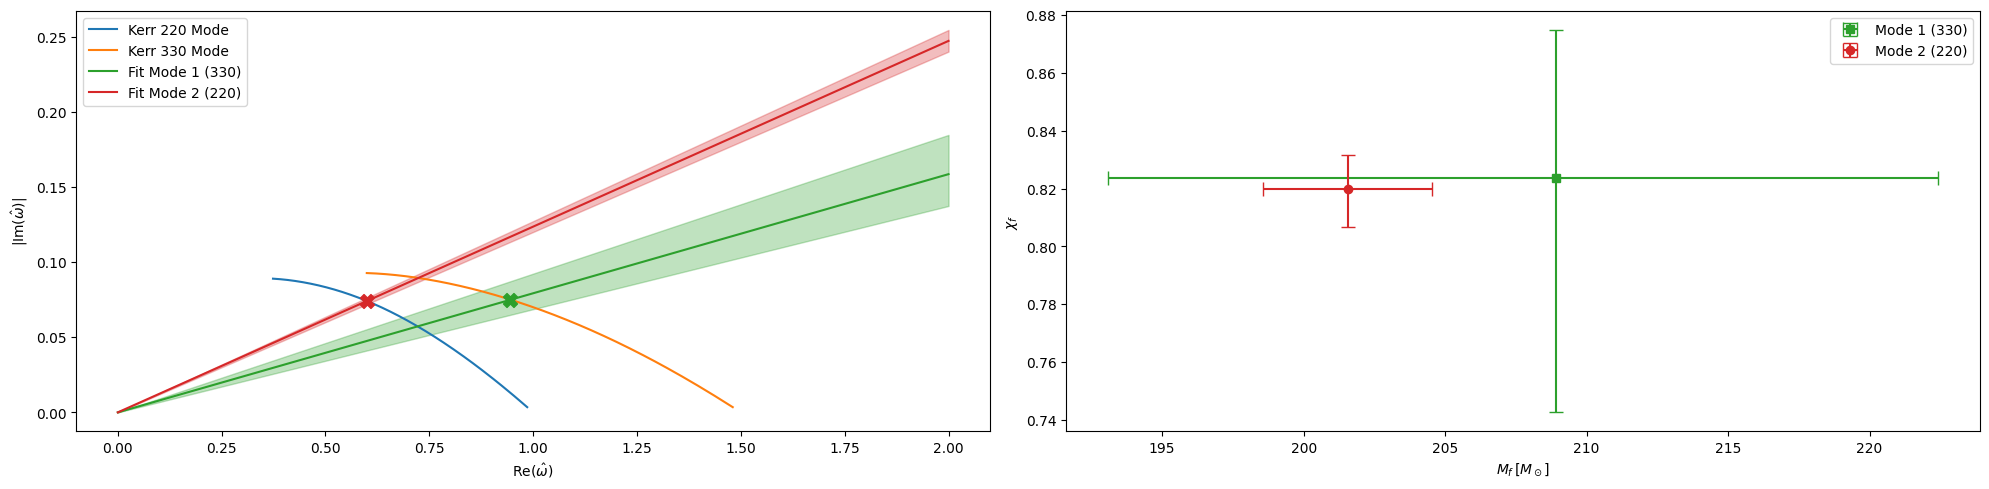

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5))

ax[0].set_xlabel(r"$\mathrm{Re}(\hat{\omega})$")
ax[0].set_ylabel(r"$|\mathrm{Im}(\hat{\omega})|$")

y220 = np.abs(omega_220.imag);  x220 = omega_220.real
y330 = np.abs(omega_330.imag);  x330 = omega_330.real

ax[0].plot(x220, y220, label='Kerr 220 Mode')
ax[0].plot(x330, y330, label='Kerr 330 Mode')

def make_g(f, tau): return 1 / (2 * np.pi * f * tau)

g1_med = make_g(f1_med, tau1_med)
g1_lo  = make_g(f1_hi,  tau1_hi)
g1_hi  = make_g(f1_lo,  tau1_lo)
g2_med = make_g(f2_med, tau2_med)
g2_lo  = make_g(f2_hi,  tau2_hi)
g2_hi  = make_g(f2_lo,  tau2_lo)

mf = np.linspace(0, 2, 1000)
c1, c2 = 'C2', 'C3'

ax[0].plot(mf, g1_med * mf, color=c1, label='Fit Mode 1 (330)')
ax[0].fill_between(mf, g1_lo * mf, g1_hi * mf, color=c1, alpha=0.3)
ax[0].plot(mf, g2_med * mf, color=c2, label='Fit Mode 2 (220)')
ax[0].fill_between(mf, g2_lo * mf, g2_hi * mf, color=c2, alpha=0.3)
ax[0].legend()

Msun_s = 4.927e-6

def crossing(xk, yk, g):
    idx = np.where(np.diff(np.sign(yk - g * xk)))[0][0]
    return float(xk[idx]), float(yk[idx]), float(chi_values[idx])

def to_Mf(x_cross, f_hz):
    return x_cross / (2 * np.pi * f_hz * Msun_s)

# Mode 1 (330) gradient ∩ 330 Kerr — compute all three then take min/max
x330_med, y330_c, chi330_med = crossing(x330, y330, g1_med)
x330_a,   _,      chi330_a   = crossing(x330, y330, g1_lo)
x330_b,   _,      chi330_b   = crossing(x330, y330, g1_hi)

Mf330_med = to_Mf(x330_med, f1_med)
Mf330_a   = to_Mf(x330_a,   f1_med)
Mf330_b   = to_Mf(x330_b,   f1_med)

chi330_lo_err = chi330_med - min(chi330_a, chi330_b)
chi330_hi_err = max(chi330_a, chi330_b) - chi330_med
Mf330_lo_err  = Mf330_med - min(Mf330_a, Mf330_b)
Mf330_hi_err  = max(Mf330_a, Mf330_b) - Mf330_med

# Mode 2 (220) gradient ∩ 220 Kerr
x220_med, y220_c, chi220_med = crossing(x220, y220, g2_med)
x220_a,   _,      chi220_a   = crossing(x220, y220, g2_lo)
x220_b,   _,      chi220_b   = crossing(x220, y220, g2_hi)

Mf220_med = to_Mf(x220_med, f2_med)
Mf220_a   = to_Mf(x220_a,   f2_med)
Mf220_b   = to_Mf(x220_b,   f2_med)

chi220_lo_err = chi220_med - min(chi220_a, chi220_b)
chi220_hi_err = max(chi220_a, chi220_b) - chi220_med
Mf220_lo_err  = Mf220_med - min(Mf220_a, Mf220_b)
Mf220_hi_err  = max(Mf220_a, Mf220_b) - Mf220_med

ax[0].scatter(x330_med, y330_c, s=100, marker='X', color=c1, zorder=5)
ax[0].scatter(x220_med, y220_c, s=100, marker='X', color=c2, zorder=5)

ax[1].set_xlabel(r"$M_f \, [M_\odot]$")
ax[1].set_ylabel(r"$\chi_f$")

ax[1].errorbar(
    Mf330_med, chi330_med,
    xerr=[[Mf330_lo_err], [Mf330_hi_err]],
    yerr=[[chi330_lo_err], [chi330_hi_err]],
    fmt='s', color=c1, capsize=5, label='Mode 1 (330)'
)
ax[1].errorbar(
    Mf220_med, chi220_med,
    xerr=[[Mf220_lo_err], [Mf220_hi_err]],
    yerr=[[chi220_lo_err], [chi220_hi_err]],
    fmt='o', color=c2, capsize=5, label='Mode 2 (220)'
)

ax[1].legend()
plt.tight_layout()
plt.show()

- We can justify our choice of t0 using this analysis.
- By running the analysis repeatedly at slight t0 deviations, we can choose a t0 at the start of a stable plateau.
- Too early, the 2-mode assumption will be wrong.
- Too late, the SNR will get too low.

In [58]:
def run_analysis(t0):
    #---
    def lnL(theta):
        A1, phi1, f1, tau1, A2, phi2, f2, tau2 = theta
        t = t_ring
        model = (A1 * np.cos(2*np.pi*f1*(t - t0) + phi1) * np.exp(-(t - t0)/tau1) +
                A2 * np.cos(2*np.pi*f2*(t - t0) + phi2) * np.exp(-(t - t0)/tau2))
        residuals = d_ring - model  # d is your on-source data, t > t0
        return -0.5 * np.sum(residuals**2 / off_std**2)
    #---
    on_time_start, on_time_end = on_times

    t_on = t[(t > on_time_start) & (t < on_time_end)]
    d_on = strain[(t > on_time_start) & (t < on_time_end)]

    t_off_1 = t[(t < on_time_start)]
    d_off_1 = strain[(t < on_time_start)]

    t_off_2 = t[(t > on_time_end)]
    d_off_2 = strain[(t > on_time_end)]

    t_ring = t_on[t_on > t0]
    d_ring = d_on[t_on > t0]

    #---

    np.random.seed(1701)

    sampler = dynesty.DynamicNestedSampler(
        lnL,
        prior_transform,
        ndim=8,
        bound='multi',    # multiellipsoid bounding (good default)
        sample='rwalk'    # random walk sampling
    )

    sampler.run_nested(print_progress=True)

    results = sampler.results

    # Resample to equal weights (important — dynesty samples are not equal weight)
    weights = np.exp(results.logwt - results.logz[-1])
    samples = dyfunc.resample_equal(results.samples, weights)

    # samples has shape (N, 8)
    # columns match your parameter order: A1, phi1, f1, tau1, A2, phi2, f2, tau2
    A1, phi1, f1, tau1 = samples[:,0], samples[:,1], samples[:,2], samples[:,3]
    A2, phi2, f2, tau2 = samples[:,4], samples[:,5], samples[:,6], samples[:,7]

    labels = [r"$A_1$", r"$\phi_1$", r"$f_1$", r"$\tau_1$",
            r"$A_2$", r"$\phi_2$", r"$f_2$", r"$\tau_2$"]

    fig = corner.corner(
        samples,
        labels=labels,
        quantiles=[0.16, 0.5, 0.84],  # 1-sigma credible intervals
        show_titles=True,
        title_fmt=".2e",
    )

    # 16th, 50th (median), 84th percentiles for each parameter
    lo, med, hi = np.percentile(samples, [16, 50, 84], axis=0)

    f1_med = med[2]
    f1_lo, f1_hi = lo[2], hi[2]

    f2_med = med[6]
    f2_lo, f2_hi = lo[6], hi[6]

    tau1_med = med[3]
    tau1_lo, tau1_hi = lo[3], hi[3]

    tau2_med = med[7]
    tau2_lo, tau2_hi = lo[7], hi[7]

    # Ensure f1/tau1 = 330 (higher freq), f2/tau2 = 220 (lower freq)
    if f2_med > f1_med:
        f1_med, f2_med = f2_med, f1_med
        f1_lo,  f2_lo  = f2_lo,  f1_lo
        f1_hi,  f2_hi  = f2_hi,  f1_hi
        tau1_med, tau2_med = tau2_med, tau1_med
        tau1_lo,  tau2_lo  = tau2_lo,  tau1_lo
        tau1_hi,  tau2_hi  = tau2_hi,  tau1_hi

    omega_220_ratio = omega_220.real / np.abs(omega_220.imag)

    target_220 = 2 * np.pi * f2_med * tau2_med
    lo_220 = 2 * np.pi * f2_lo * tau2_lo
    hi_220 = 2 * np.pi * f2_hi * tau2_hi

    chi_med_220 = np.interp(target_220, omega_220_ratio, chi_values)
    chi_lo_220  = np.interp(lo_220, omega_220_ratio, chi_values)
    chi_hi_220  = np.interp(hi_220, omega_220_ratio, chi_values)

    omega_330_ratio = omega_330.real / np.abs(omega_330.imag)

    target_330 = 2 * np.pi * f1_med * tau1_med
    lo_330 = 2 * np.pi * f1_lo * tau1_lo
    hi_330 = 2 * np.pi * f1_hi * tau1_hi

    chi_med_330 = np.interp(target_330, omega_330_ratio, chi_values)
    chi_lo_330  = np.interp(lo_330, omega_330_ratio, chi_values)
    chi_hi_330  = np.interp(hi_330, omega_330_ratio, chi_values)

    # Calculate Masses for 220 mode (uses f2)
    omega_hat_med_220, _, _ = mode_220(chi_med_220)
    omega_hat_lo_220, _, _  = mode_220(chi_lo_220)
    omega_hat_hi_220, _, _  = mode_220(chi_hi_220)

    M_med_220 = omega_hat_med_220.real / (2 * np.pi * f2_med)
    M_lo_220  = omega_hat_lo_220.real  / (2 * np.pi * f2_hi)
    M_hi_220  = omega_hat_hi_220.real  / (2 * np.pi * f2_lo)

    M_med_220 = convert_to_Msun(M_med_220)
    M_lo_220  = convert_to_Msun(M_lo_220)
    M_hi_220  = convert_to_Msun(M_hi_220)

    # Calculate Masses for 330 mode (uses f1)
    omega_hat_med_330, _, _ = mode_330(chi_med_330)
    omega_hat_lo_330, _, _  = mode_330(chi_lo_330)
    omega_hat_hi_330, _, _  = mode_330(chi_hi_330)

    M_med_330 = omega_hat_med_330.real / (2 * np.pi * f1_med)
    M_lo_330  = omega_hat_lo_330.real  / (2 * np.pi * f1_hi)
    M_hi_330  = omega_hat_hi_330.real  / (2 * np.pi * f1_lo)

    M_med_330 = convert_to_Msun(M_med_330)
    M_lo_330  = convert_to_Msun(M_lo_330)
    M_hi_330  = convert_to_Msun(M_hi_330)

    return (f1_med, f1_lo, f1_hi), (f2_med, f2_lo, f2_hi), (tau1_med, tau1_lo, tau1_hi), (tau2_med, tau2_lo, tau2_hi), (M_med_220, M_lo_220, M_hi_220), (M_med_330, M_lo_330, M_hi_330)


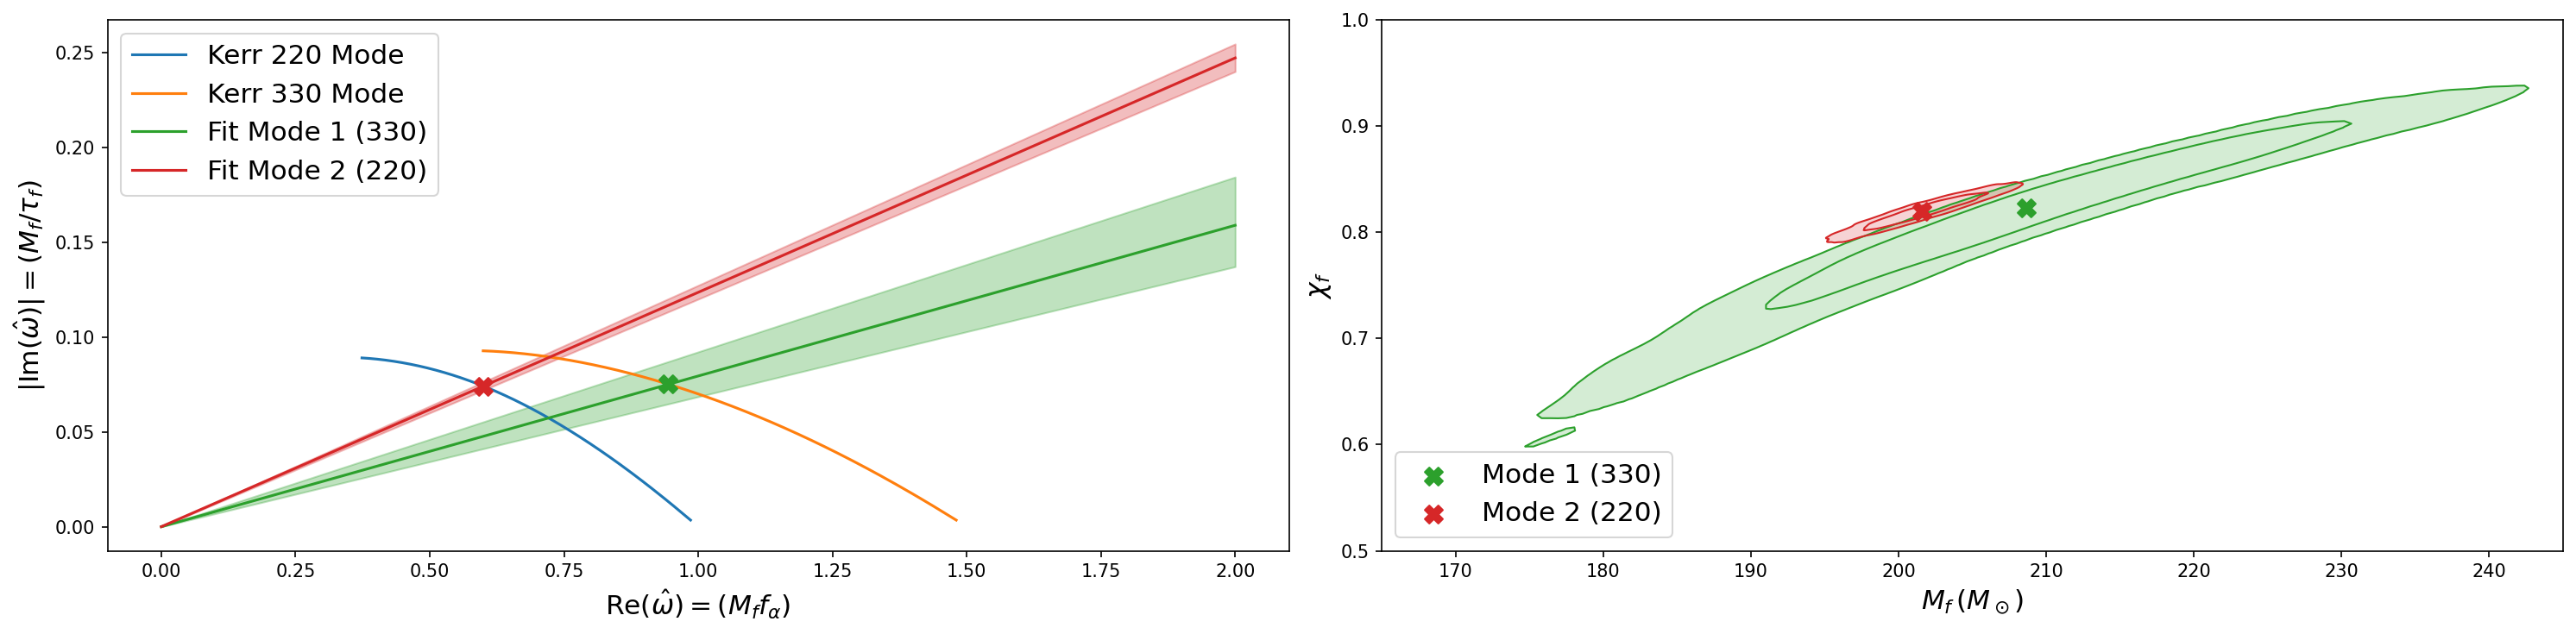

In [29]:
from scipy.stats import gaussian_kde

# ── Propagate posterior samples → (Mf, χf) ──────────────────────────────────
Msun_s = 4.927e-6
def make_g(f, tau): return 1 / (2 * np.pi * f * tau)
y220 = np.abs(omega_220.imag); x220 = omega_220.real
y330 = np.abs(omega_330.imag); x330 = omega_330.real

def crossing(xk, yk, g):
    idx = np.where(np.diff(np.sign(yk - g * xk)))[0][0]
    return float(xk[idx]), float(yk[idx]), float(chi_values[idx])
def to_Mf(x_cross, f_hz):
    return x_cross / (2 * np.pi * f_hz * Msun_s)

# Per-sample swap: f1/tau1 = 330 (higher freq), f2/tau2 = 220 (lower)
swap   = samples[:, 6] > samples[:, 2]
f1_s   = np.where(swap, samples[:, 6], samples[:, 2])
tau1_s = np.where(swap, samples[:, 7], samples[:, 3])
f2_s   = np.where(swap, samples[:, 2], samples[:, 6])
tau2_s = np.where(swap, samples[:, 3], samples[:, 7])

Mf330_s, chi330_s, Mf220_s, chi220_s = [], [], [], []
for f1i, t1i, f2i, t2i in zip(f1_s, tau1_s, f2_s, tau2_s):
    try:
        xc, _, chi_c = crossing(x330, y330, make_g(f1i, t1i))
        Mf330_s.append(to_Mf(xc, f1i)); chi330_s.append(chi_c)
    except IndexError: pass
    try:
        xc, _, chi_c = crossing(x220, y220, make_g(f2i, t2i))
        Mf220_s.append(to_Mf(xc, f2i)); chi220_s.append(chi_c)
    except IndexError: pass

Mf330_s, chi330_s = np.array(Mf330_s), np.array(chi330_s)
Mf220_s, chi220_s = np.array(Mf220_s), np.array(chi220_s)

# ── KDE contour helper ───────────────────────────────────────────────────────
def plot_kde_contours(ax, Mf_s, chi_s, color):
    kde = gaussian_kde(np.vstack([Mf_s, chi_s]))
    gx = np.linspace(Mf_s.min(), Mf_s.max(), 200)
    gy = np.linspace(chi_s.min(), chi_s.max(), 200)
    X, Y = np.meshgrid(gx, gy)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    z_sorted = np.sort(Z.ravel())[::-1]
    cumsum = np.cumsum(z_sorted) / z_sorted.sum()
    t68 = z_sorted[np.searchsorted(cumsum, 0.68)]
    t95 = z_sorted[np.searchsorted(cumsum, 0.95)]
    ax.contourf(X, Y, Z, levels=[t95, t68, Z.max()], colors=[color, color], alpha=0.2)
    ax.contour(X, Y, Z, levels=[t95, t68], colors=[color], linewidths=1)

# ── Reproduce figure ─────────────────────────────────────────────────────────
c1, c2 = 'C2', 'C3'
g1_med = make_g(f1_med, tau1_med); g1_lo = make_g(f1_hi, tau1_hi); g1_hi = make_g(f1_lo, tau1_lo)
g2_med = make_g(f2_med, tau2_med); g2_lo = make_g(f2_hi, tau2_hi); g2_hi = make_g(f2_lo, tau2_lo)
mf = np.linspace(0, 2, 1000)

fig, ax = plt.subplots(1, 2, figsize=(20, 5), dpi=150)

ax[0].set_xlabel(r"$\mathrm{Re}(\hat{\omega}) = (M_ff_\alpha)$",fontsize=15)
ax[0].set_ylabel(r"$|\mathrm{Im}(\hat{\omega})| = (M_f/\tau_f)$",fontsize=15)
ax[0].plot(x220, y220, label='Kerr 220 Mode')
ax[0].plot(x330, y330, label='Kerr 330 Mode')
ax[0].plot(mf, g1_med * mf, color=c1, label='Fit Mode 1 (330)')
ax[0].fill_between(mf, g1_lo * mf, g1_hi * mf, color=c1, alpha=0.3)
ax[0].plot(mf, g2_med * mf, color=c2, label='Fit Mode 2 (220)')
ax[0].fill_between(mf, g2_lo * mf, g2_hi * mf, color=c2, alpha=0.3)
x330_med, y330_c, _ = crossing(x330, y330, g1_med)
x220_med, y220_c, _ = crossing(x220, y220, g2_med)
ax[0].scatter(x330_med, y330_c, s=100, marker='X', color=c1, zorder=5)
ax[0].scatter(x220_med, y220_c, s=100, marker='X', color=c2, zorder=5)
ax[0].legend(fontsize=15)

ax[1].set_xlabel(r"$M_f \, (M_\odot)$",fontsize=15)
ax[1].set_ylabel(r"$\chi_f$",fontsize=15)
plot_kde_contours(ax[1], Mf330_s, chi330_s, c1)
plot_kde_contours(ax[1], Mf220_s, chi220_s, c2)
ax[1].scatter(np.median(Mf330_s), np.median(chi330_s), s=100, marker='X', color=c1, zorder=5, label='Mode 1 (330)')
ax[1].scatter(np.median(Mf220_s), np.median(chi220_s), s=100, marker='X', color=c2, zorder=5, label='Mode 2 (220)')
ax[1].legend(fontsize=15, loc='lower left')
ax[1].set_xlim(165,245)
ax[1].set_ylim(0.5,1)

plt.tight_layout()
plt.show()


t0 = 13.99706  (422 datapoints)


32853it [03:20, 163.58it/s, batch: 4 | bound: 5 | nc: 1 | ncall: 861413 | eff(%):  3.755 | loglstar: -391.152 < -383.898 < -385.909 | logz: -431.373 +/-  0.232 | stop:  0.915]            


t0 = 13.99767  (419 datapoints)


30088it [02:48, 178.26it/s, batch: 4 | bound: 5 | nc: 1 | ncall: 784125 | eff(%):  3.772 | loglstar: -390.061 < -383.031 < -384.935 | logz: -425.053 +/-  0.218 | stop:  0.931]           


t0 = 13.99829  (417 datapoints)


...

27476it [02:18, 198.11it/s, batch: 4 | bound: 5 | nc: 1 | ncall: 707863 | eff(%):  3.809 | loglstar: -153.883 < -147.168 < -148.968 | logz: -184.181 +/-  0.206 | stop:  0.828]         


t0 = 14.02645  (301 datapoints)


24576it [02:36, 157.19it/s, batch: 4 | bound: 4 | nc: 1 | ncall: 628825 | eff(%):  3.826 | loglstar: -154.521 < -147.308 < -149.902 | logz: -178.468 +/-  0.184 | stop:  0.940]         


t0 = 14.02706  (299 datapoints)


25389it [02:17, 185.09it/s, batch: 3 | bound: 6 | nc: 1 | ncall: 651759 | eff(%):  3.816 | loglstar: -153.541 < -145.981 < -148.068 | logz: -179.886 +/-  0.202 | stop:  0.857]         


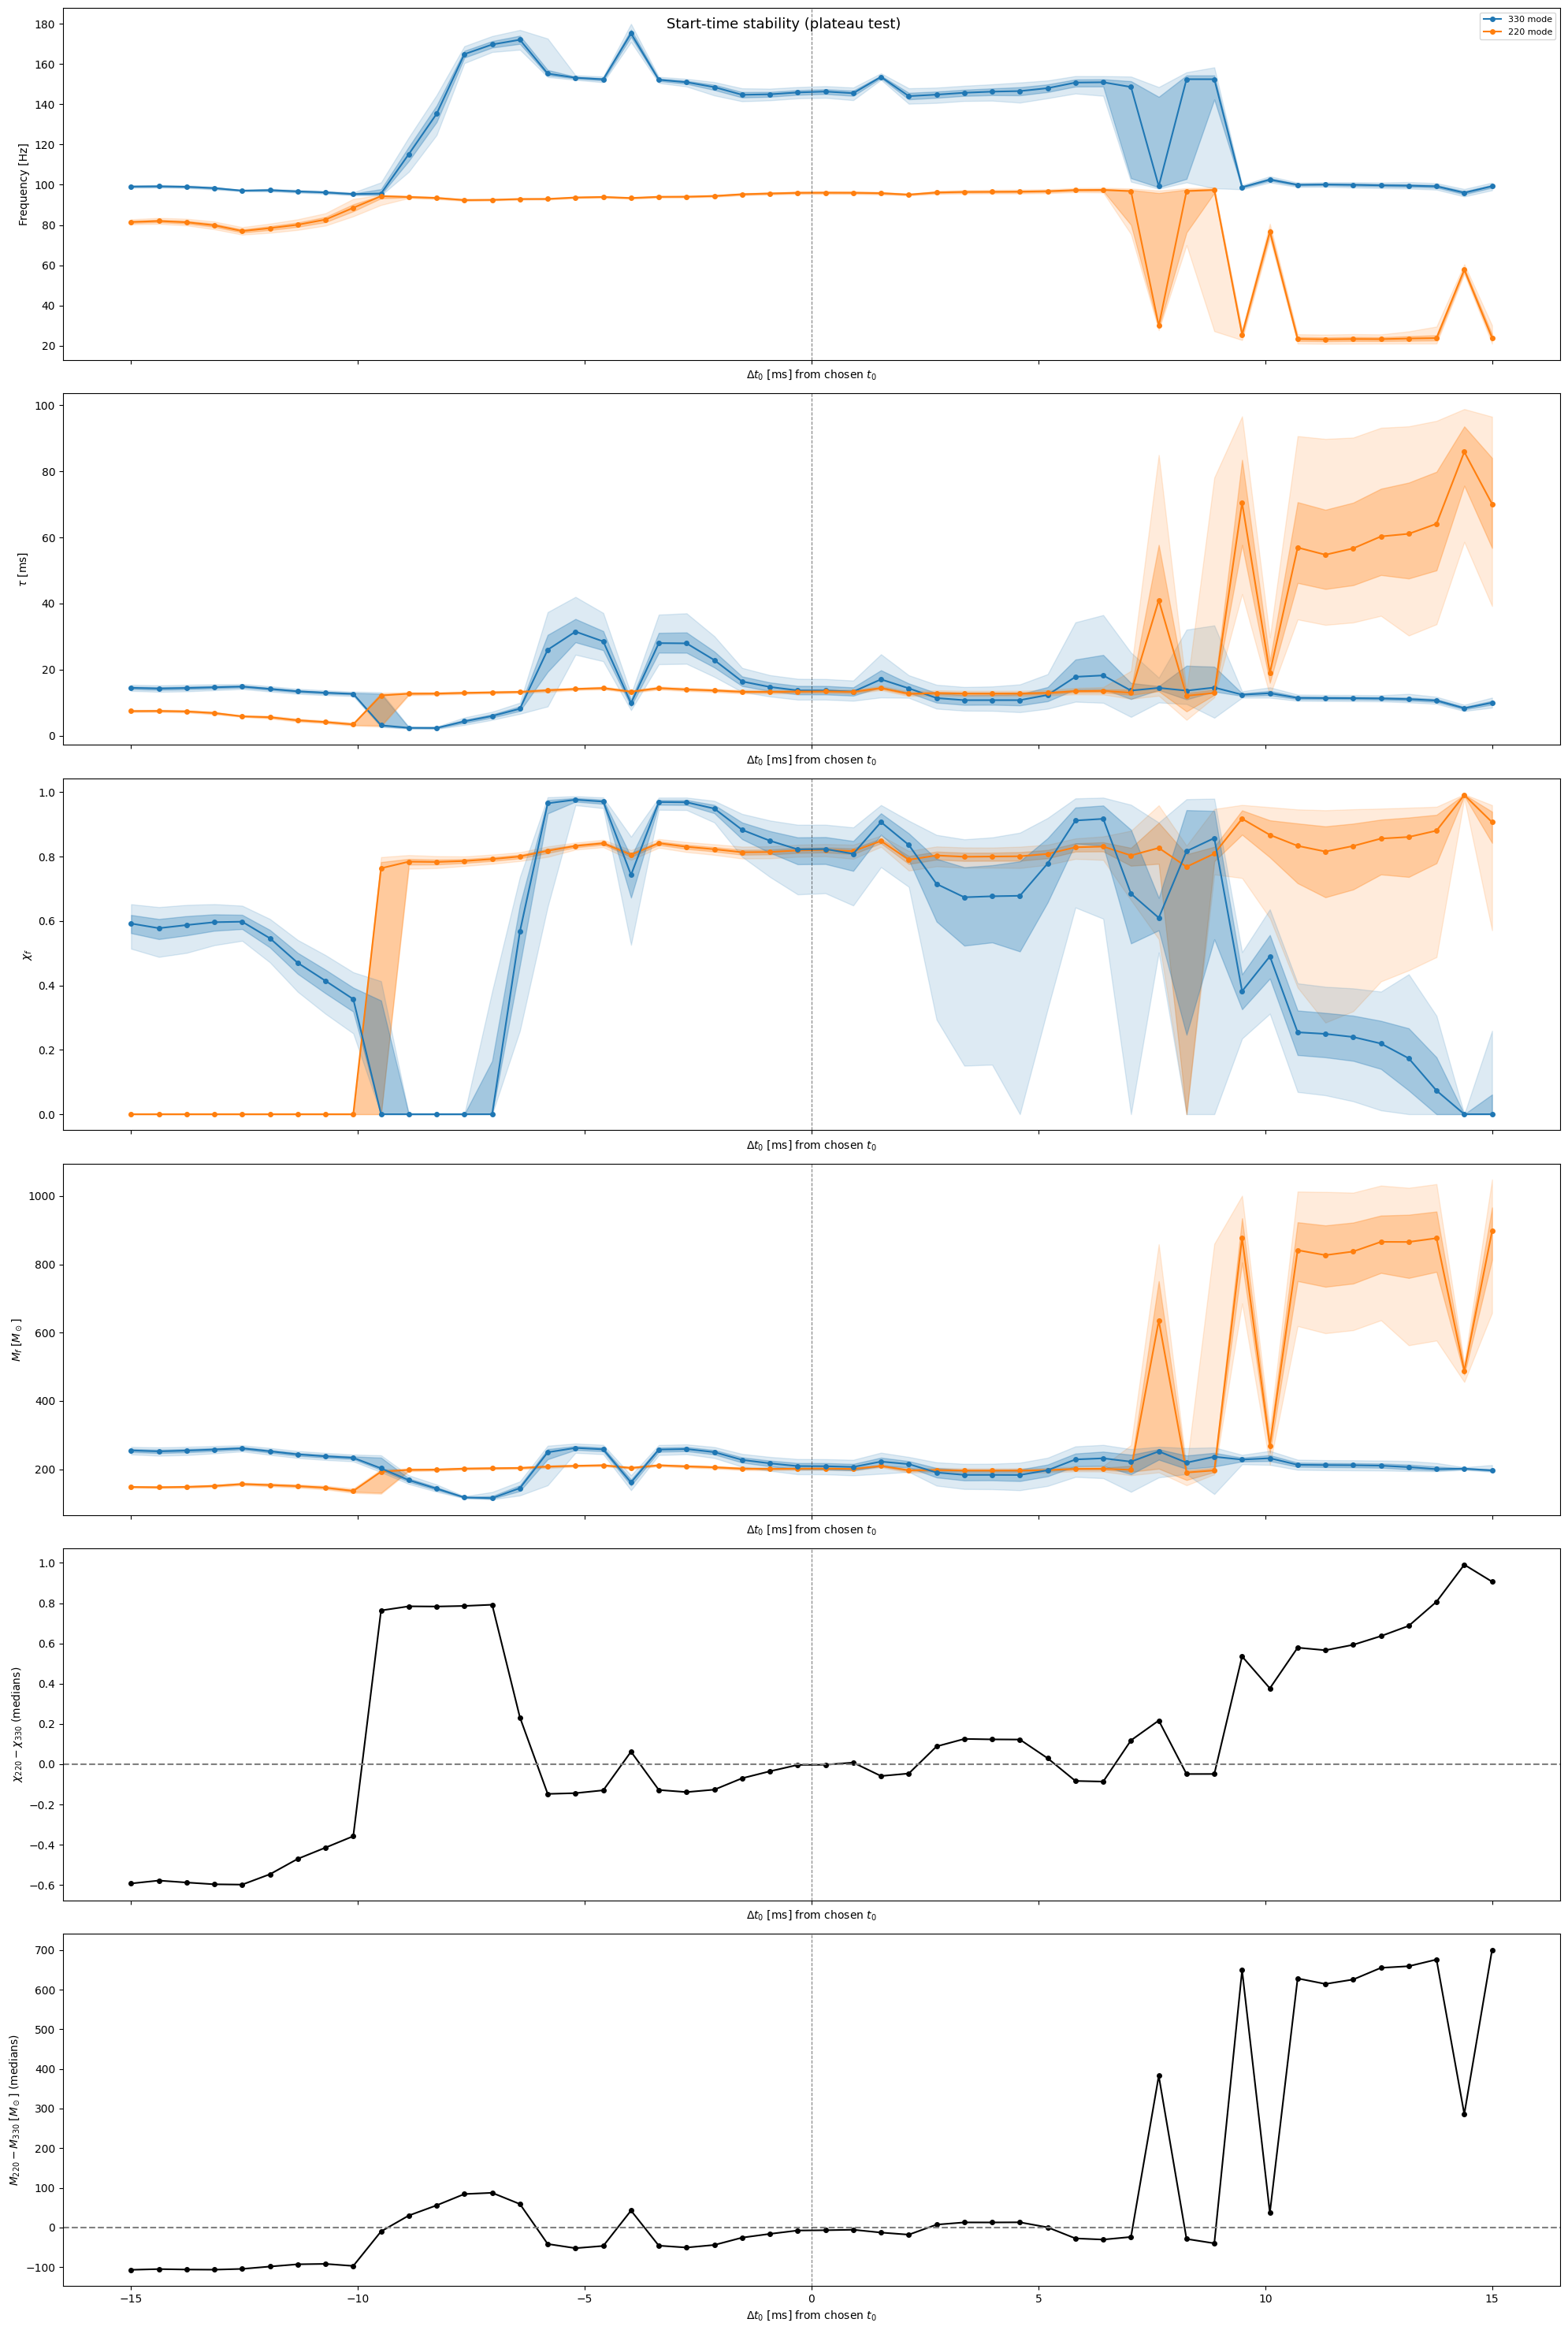

In [66]:
# ── Plateau test: start-time stability ───────────────────────────────────────

t0_offsets_ms = np.linspace(-15, 15, 50)
t0_values = t0 + t0_offsets_ms * 1e-3

# Kerr ratio grids for vectorised chi/M extraction from posterior samples
_r220  = omega_220.real / np.abs(omega_220.imag) # ratio
_r330  = omega_330.real / np.abs(omega_330.imag)
_re220 = omega_220.real # real
_re330 = omega_330.real

def _process_samples(samp):
    """Equal-weight samples (N,8) → dict of (5,) percentile arrays."""
    s = samp.copy()
    # Per-sample label sort: f1 = 330 (higher freq), f2 = 220 (lower freq)
    # This performs the swap if required
    swap = s[:, 6] > s[:, 2]
    f1   = np.where(swap, s[:, 6], s[:, 2])
    tau1 = np.where(swap, s[:, 7], s[:, 3])
    f2   = np.where(swap, s[:, 2], s[:, 6])
    tau2 = np.where(swap, s[:, 3], s[:, 7])

    # Calculate the chi and M values
    chi220 = np.interp(2*np.pi * f2 * tau2, _r220, chi_values)
    chi330 = np.interp(2*np.pi * f1 * tau1, _r330, chi_values)
    M220   = convert_to_Msun(np.interp(chi220, chi_values, _re220) / (2*np.pi * f2))
    M330   = convert_to_Msun(np.interp(chi330, chi_values, _re330) / (2*np.pi * f1))

    # Calculate the credible intervals from the posterior samples of each value
    pct = [5, 25, 50, 75, 95]
    return {k: np.percentile(v, pct) for k, v in [
        ('f1', f1), ('tau1', tau1), ('f2', f2), ('tau2', tau2),
        ('chi220', chi220), ('chi330', chi330), ('M220', M220), ('M330', M330),
    ]}

# --- Run sampler at each t0---
plateau_results = []
for t0_val in t0_values:
    # Take the data subsets for those values
    t_ring_loc = t_on[t_on > t0_val] 
    d_ring_loc = d_on[t_on > t0_val]
    print(f"t0 = {t0_val:.5f}  ({len(t_ring_loc)} datapoints)", flush=True)

    # Redefine lnL for this loop t0
    def _lnL(theta, _t=t_ring_loc, _d=d_ring_loc, _t0=t0_val):
        A1, phi1, f1, tau1, A2, phi2, f2, tau2 = theta
        dt = _t - _t0
        m = (A1 * np.cos(2*np.pi*f1*dt + phi1) * np.exp(-dt/tau1) +
            A2 * np.cos(2*np.pi*f2*dt + phi2) * np.exp(-dt/tau2))
        return -0.5 * np.sum((_d - m)**2 / off_std**2)

    # Sample
    np.random.seed(1701)
    sampler = dynesty.DynamicNestedSampler(
        _lnL, prior_transform, ndim=8, bound='multi', sample='rwalk'
    )
    sampler.run_nested(print_progress=True)
    w    = np.exp(sampler.results.logwt - sampler.results.logz[-1])
    samp = dyfunc.resample_equal(sampler.results.samples, w)
    plateau_results.append(_process_samples(samp))

# --- Plot ---
def _collect(key):
    return np.array([r[key] for r in plateau_results])  # (n_t0, 5)

def _band(ax, x, data, color, label=None):
    """data columns: 5th, 25th, 50th, 75th, 95th percentile."""
    ax.fill_between(x, data[:, 0], data[:, 4], color=color, alpha=0.15)  # 90%
    ax.fill_between(x, data[:, 1], data[:, 3], color=color, alpha=0.30)  # 50%
    ax.plot(x, data[:, 2], color=color, marker='o', ms=4, label=label)

x = t0_offsets_ms
fig, axes = plt.subplots(6, 1, figsize=(20, 30), sharex=True)

_band(axes[0], x, _collect('f1'),          'C0', '330 mode')
_band(axes[0], x, _collect('f2'),          'C1', '220 mode')
axes[0].set_ylabel('Frequency [Hz]')
axes[0].legend(fontsize=8)

_band(axes[1], x, _collect('tau1') * 1e3, 'C0', '330 mode')
_band(axes[1], x, _collect('tau2') * 1e3, 'C1', '220 mode')
axes[1].set_ylabel(r'$\tau$ [ms]')

_band(axes[2], x, _collect('chi220'),      'C1', '220 mode')
_band(axes[2], x, _collect('chi330'),      'C0', '330 mode')
axes[2].set_ylabel(r'$\chi_f$')

_band(axes[3], x, _collect('M220'),        'C1', '220 mode')
_band(axes[3], x, _collect('M330'),        'C0', '330 mode')
axes[3].set_ylabel(r'$M_f\;[M_\odot]$')

axes[4].plot(x, _collect('chi220')[:, 2] - _collect('chi330')[:, 2], 'k-o', ms=4)
axes[4].axhline(0, color='grey', ls='--')
axes[4].set_ylabel(r'$\chi_{220} - \chi_{330}$ (medians)')

axes[5].plot(x, _collect('M220')[:, 2] - _collect('M330')[:, 2], 'k-o', ms=4)
axes[5].axhline(0, color='grey', ls='--')
axes[5].set_ylabel(r'$M_{220} - M_{330}\;[M_\odot]$ (medians)')

for ax in axes.flat:
    ax.axvline(0, color='k', ls='--', lw=0.8, alpha=0.5)
for ax in axes:
    ax.set_xlabel(r'$\Delta t_0$ [ms] from chosen $t_0$')

fig.suptitle('Start-time stability (plateau test)', fontsize=13)
plt.tight_layout()
plt.show()